# DATA PREPROCESSING AND FEATURE ENGINEERING FOR GOOGLE PLAYSTORE DATASET

***

## DATASET =   

**'https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv'**

***


**Importing necessary libraries**

In [781]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


## DATA COLLECTION
***

In [782]:
df = pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')


In [783]:
#view data
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [784]:
df.shape # rows * column

(10841, 13)

In [785]:
df.columns # All columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [786]:
df.info() # Datatype and Structures

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


## DATA CLEANING

***

In [787]:
df.isnull().sum() # checking null values

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

There is highest null values in 'Rating' Category

In [788]:
Columns= df.columns

Getting no. of unique values in each column

In [789]:
for i in Columns:
    print(f"No. of unique value in {i} column: ", df[i].nunique())
    print(' ')

No. of unique value in App column:  9660
 
No. of unique value in Category column:  34
 
No. of unique value in Rating column:  40
 
No. of unique value in Reviews column:  6002
 
No. of unique value in Size column:  462
 
No. of unique value in Installs column:  22
 
No. of unique value in Type column:  3
 
No. of unique value in Price column:  93
 
No. of unique value in Content Rating column:  6
 
No. of unique value in Genres column:  120
 
No. of unique value in Last Updated column:  1378
 
No. of unique value in Current Ver column:  2832
 
No. of unique value in Android Ver column:  33
 


In [790]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


Checking Duplicate Values

In [791]:
df[df.duplicated(subset='App', keep=False)].sort_values('App')



,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3202,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device
3118,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device
3103,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device
8291,wetter.com - Weather and Radar,WEATHER,4.2,189310,38M,"10,000,000+",Free,0,Everyone,Weather,"August 6, 2018",Varies with device,Varies with device


In [792]:
df.groupby('App').size().sort_values(ascending=False).head(20)


App
ROBLOX                                                9
CBS Sports App - Scores, News, Stats & Watch Live     8
Candy Crush Saga                                      7
Duolingo: Learn Languages Free                        7
8 Ball Pool                                           7
ESPN                                                  7
Bleacher Report: sports news, scores, & highlights    6
Zombie Catchers                                       6
Sniper 3D Gun Shooter: Free Shooting Games - FPS      6
Temple Run 2                                          6
Bubble Shooter                                        6
Nick                                                  6
Bowmasters                                            6
slither.io                                            6
Subway Surfers                                        6
Helix Jump                                            6
Farm Heroes Saga                                      5
Angry Birds Classic                         

App got the highest number of duplicate values


#Dropping All Duplicate values

In [793]:
df.drop_duplicates(inplace=True)

In [794]:
df[df.duplicated(subset='App',keep=False)].sort_values(by='App').head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
5415,365Scores - Live Scores,SPORTS,4.6,666246,25M,"10,000,000+",Free,0,Everyone,Sports,"July 29, 2018",5.5.9,4.1 and up
3083,365Scores - Live Scores,SPORTS,4.6,666521,25M,"10,000,000+",Free,0,Everyone,Sports,"July 29, 2018",5.5.9,4.1 and up
1755,8 Ball Pool,GAME,4.5,14200344,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up
1703,8 Ball Pool,GAME,4.5,14198602,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up
1871,8 Ball Pool,GAME,4.5,14201891,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up


In [795]:
df[df['App']=='ROBLOX']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1653,ROBLOX,GAME,4.5,4447388,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1701,ROBLOX,GAME,4.5,4447346,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1748,ROBLOX,GAME,4.5,4448791,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1841,ROBLOX,GAME,4.5,4449882,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
1870,ROBLOX,GAME,4.5,4449910,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
2016,ROBLOX,FAMILY,4.5,4449910,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
2088,ROBLOX,FAMILY,4.5,4450855,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
2206,ROBLOX,FAMILY,4.5,4450890,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
4527,ROBLOX,FAMILY,4.5,4443407,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up


we do still have the duplicated values, but only we two column different that is category and reviews

**we will only keep those with highest review**

In [796]:
# sort values by reviews
#then filter by descending ( highest first)
#drop duplicate values of app and only keep the first one ( highhest rating)

df=df.sort_values(by='Reviews',ascending=False).drop_duplicates(subset='App',keep='first')

## Rechecking

In [797]:
df.groupby('App').size().sort_values(ascending=False).head(10)

App
"i DT" Fútbol. Todos Somos Técnicos.                1
My Talking Tom                                      1
My Teacher - Classroom Play                         1
My Telcel                                           1
My Tele2                                            1
My Theme Park: RollerCoaster & Water Park Tycoon    1
My Truck                                            1
My Virtual Boyfriend                                1
My Vodacom SA                                       1
My Vodafone (GR)                                    1
dtype: int64

In [798]:
df[df.duplicated(subset='App',keep=False)].sort_values(by='App').head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [799]:
df[df['App']=='ROBLOX']


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2206,ROBLOX,FAMILY,4.5,4450890,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up


In [800]:
df.shape

(9660, 13)

We got 9660 rows after removing duplicates

In [801]:
df.duplicated().sum()

0

In [802]:
df['Rating'].unique()

array([ 4.2,  3.3,  4.7,  4. ,  4.3,  3.7,  4.5,  4.6,  4.4,  3.9,  4.1,
        2.4,  3.6,  2.9,  nan,  4.8,  2.8,  3.5,  1.9,  3.8,  3. ,  3.2,
        4.9,  2.6,  3.4,  5. ,  2.7,  2. ,  2.3,  2.2,  2.1,  2.5,  3.1,
        1.7,  1.6,  1.5,  1.8,  1. ,  1.4,  1.2, 19. ])

In [803]:
df[df['Rating'].isnull()].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
3621,Voice Tables - no internet,PARENTING,NaN,970,71M,"100,000+",Free,0,Everyone,Parenting,"May 28, 2018",2.0,4.0.3 and up
10808,lesparticuliers.fr,LIFESTYLE,NaN,96,1.0M,"50,000+",Free,0,Everyone,Lifestyle,"November 25, 2014",1.5,2.3 and up
10818,Gold Quote - Gold.fr,FINANCE,NaN,96,1.5M,"10,000+",Free,0,Everyone,Finance,"May 19, 2016",2.3,2.2 and up
9834,Recettes Faciles et Rapides,FOOD_AND_DRINK,NaN,95,12M,"50,000+",Free,0,Everyone,Food & Drink,"January 6, 2018",3.0.1,2.3 and up
1177,Easy and Fast Recipes,FOOD_AND_DRINK,NaN,95,12M,"50,000+",Free,0,Everyone,Food & Drink,"January 6, 2018",3.0.1,2.3 and up


**Leaving rating as it is for now because NaN here means "no rating given by users**

**not an actual low rating. Filling it with 0 or median would misrepresent reality**

**so we will treat missing ratings as a separate case (unrated apps)**
***


Changing the datatype of rating to float

In [804]:
df['Rating']=df['Rating'].astype(float)

In [805]:
df['Rating'].dtype

dtype('float64')

***

**#Cleaning "Reviews" Column**

In [806]:
df['Reviews'].unique() # checking unique values

array(['9992', '999', '9975', ..., '10', '1', '0'], dtype=object)

In [807]:
df['Reviews'].dtype # checking data type


dtype('O')

In [808]:
df[(~df["Reviews"].str.isnumeric())] #getting values that are not numeric in this column

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


we got 3.0M as non numeric value in this column

In [809]:
df['Reviews']= df['Reviews'].astype(str) # converting dtype into string to apply replace function

removing that "M" and then converting it back to millions ( m = million)

In [810]:
def convert_reviews(a):
    if isinstance(a,str) and 'M' in a:
       return  float(a.replace('M',''))*1000000 # converting data type as well 
    else:
        return float(a)
 

In [811]:
df['Reviews']=df['Reviews'].apply(convert_reviews) # Applying the above function

In [812]:
df.loc[10472] # checking if it worked or not


App               Life Made WI-Fi Touchscreen Photo Frame
Category                                              1.9
Rating                                               19.0
Reviews                                         3000000.0
Size                                               1,000+
Installs                                             Free
Type                                                    0
Price                                            Everyone
Content Rating                                        NaN
Genres                                  February 11, 2018
Last Updated                                       1.0.19
Current Ver                                    4.0 and up
Android Ver                                           NaN
Name: 10472, dtype: object

In [813]:
df[df['App']=='Life Made WI-Fi Touchscreen Photo Frame'] # worked well

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3000000.0,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [814]:
df['Reviews'].astype(float)

2989    9992.0
4970     999.0
2705    9975.0
3229    9971.0
3049    9971.0
         ...  
9190       0.0
2460       0.0
2461       0.0
2462       0.0
5846       0.0
Name: Reviews, Length: 9660, dtype: float64

In [815]:
df['Reviews'].dtype

dtype('float64')

***

**#Cleaning 'Size' Column**

checking unique values in size

In [816]:
df['Size'].unique()

array(['31M', '91k', '18M', '22M', '33M', 'Varies with device', '5.5M',
       '10M', '38M', '3.7M', '96M', '15M', '97M', '2.9M', '2.8M', '3.9M',
       '49M', '3.2M', '75M', '9.4M', '71M', '6.6M', '19M', '1.1M', '13M',
       '63M', '2.7M', '39M', '51M', '74M', '99M', '27M', '40M', '59M',
       '4.5M', '37M', '55M', '16M', '70M', '7.2M', '73k', '2.0M', '9.7M',
       '6.3M', '3.4M', '720k', '9.9M', '14M', '7.9M', '45M', '20M',
       '6.7M', '1.3M', '87M', '8.9M', '598k', '3.5M', '2.6M', '1.9M',
       '23M', '26M', '3.6M', '30M', '5.1M', '53M', '9.0M', '93k', '4.1M',
       '28M', '25M', '2.5M', '3.8M', '1.0M', '54M', '79M', '12M', '1.5M',
       '5.8M', '82M', '4.7M', '58M', '7.6M', '61M', '7.0M', '64M', '3.1M',
       '118k', '696k', '44M', '411k', '1.2M', '17M', '60M', '57M', '43M',
       '21M', '11M', '9.3M', '6.5M', '3.0M', '1.7M', '6.1M', '387k',
       '8.7M', '9.2M', '35M', '7.3M', '5.4M', '5.0M', '98M', '5.6M',
       '1.6M', '5.7M', '924k', '36M', '2.4M', '383k', '8.6M', 

In [817]:
df['Size'].dtype # checking data type

dtype('O')

Cleaning unwanted character like +,","

In [818]:
## removing unwanted characters
char_to_remove = ['+',',']
for item in char_to_remove:
    df['Size']=df['Size'].str.replace(item,'')

df['Size'].unique()

array(['31M', '91k', '18M', '22M', '33M', 'Varies with device', '5.5M',
       '10M', '38M', '3.7M', '96M', '15M', '97M', '2.9M', '2.8M', '3.9M',
       '49M', '3.2M', '75M', '9.4M', '71M', '6.6M', '19M', '1.1M', '13M',
       '63M', '2.7M', '39M', '51M', '74M', '99M', '27M', '40M', '59M',
       '4.5M', '37M', '55M', '16M', '70M', '7.2M', '73k', '2.0M', '9.7M',
       '6.3M', '3.4M', '720k', '9.9M', '14M', '7.9M', '45M', '20M',
       '6.7M', '1.3M', '87M', '8.9M', '598k', '3.5M', '2.6M', '1.9M',
       '23M', '26M', '3.6M', '30M', '5.1M', '53M', '9.0M', '93k', '4.1M',
       '28M', '25M', '2.5M', '3.8M', '1.0M', '54M', '79M', '12M', '1.5M',
       '5.8M', '82M', '4.7M', '58M', '7.6M', '61M', '7.0M', '64M', '3.1M',
       '118k', '696k', '44M', '411k', '1.2M', '17M', '60M', '57M', '43M',
       '21M', '11M', '9.3M', '6.5M', '3.0M', '1.7M', '6.1M', '387k',
       '8.7M', '9.2M', '35M', '7.3M', '5.4M', '5.0M', '98M', '5.6M',
       '1.6M', '5.7M', '924k', '36M', '2.4M', '383k', '8.6M', 

Replacing "varies with device" with nan values

we will handle this nan value later

In [819]:
##replacing "varies with device" with nan values
df['Size']=df['Size'].replace('Varies with device',np.nan)

Removing character like m and k and then multiplying by 1000000 and 1000 (converting mb and kb to b)

In [820]:
def replace_char(x):
    if isinstance(x,str) and 'M' in x:
        return float(x.replace('M',''))*1000000
    elif isinstance(x,str) and ('k' in x or  'K' in x):
        return float(x.replace('k','').replace('K',''))*1000
    else:
        return float(x)
       



In [821]:
df['Size']=df['Size'].apply(replace_char) # applying the above function

In [822]:
df['Size'].unique()

array([3.10e+07, 9.10e+04, 1.80e+07, 2.20e+07, 3.30e+07,      nan,
       5.50e+06, 1.00e+07, 3.80e+07, 3.70e+06, 9.60e+07, 1.50e+07,
       9.70e+07, 2.90e+06, 2.80e+06, 3.90e+06, 4.90e+07, 3.20e+06,
       7.50e+07, 9.40e+06, 7.10e+07, 6.60e+06, 1.90e+07, 1.10e+06,
       1.30e+07, 6.30e+07, 2.70e+06, 3.90e+07, 5.10e+07, 7.40e+07,
       9.90e+07, 2.70e+07, 4.00e+07, 5.90e+07, 4.50e+06, 3.70e+07,
       5.50e+07, 1.60e+07, 7.00e+07, 7.20e+06, 7.30e+04, 2.00e+06,
       9.70e+06, 6.30e+06, 3.40e+06, 7.20e+05, 9.90e+06, 1.40e+07,
       7.90e+06, 4.50e+07, 2.00e+07, 6.70e+06, 1.30e+06, 8.70e+07,
       8.90e+06, 5.98e+05, 3.50e+06, 2.60e+06, 1.90e+06, 2.30e+07,
       2.60e+07, 3.60e+06, 3.00e+07, 5.10e+06, 5.30e+07, 9.00e+06,
       9.30e+04, 4.10e+06, 2.80e+07, 2.50e+07, 2.50e+06, 3.80e+06,
       1.00e+06, 5.40e+07, 7.90e+07, 1.20e+07, 1.50e+06, 5.80e+06,
       8.20e+07, 4.70e+06, 5.80e+07, 7.60e+06, 6.10e+07, 7.00e+06,
       6.40e+07, 3.10e+06, 1.18e+05, 6.96e+05, 4.40e+07, 4.11e

In [823]:
df['Size'].dtype


dtype('float64')

Making a separate column for "Varies with device" because it allows us to analyze it later.

It can also provide information about sizes that vary by device,

 which wouldn’t be possible if we simply dropped this column or left it as NaN.

In [824]:
## making seperate column for varies with device
df['Size_varies_w_device']= df['Size'].isna()

In [825]:
df.head(10) 

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_varies_w_device
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,"1,000,000+",Free,0,Everyone,Sports,"May 23, 2018",6.5,4.1 and up,False
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,"100,000+",Free,0,Everyone,Tools,"December 17, 2013",3.2,2.2 and up,False
2705,SnipSnap Coupon App,SHOPPING,4.2,9975.0,18000000.0,"1,000,000+",Free,0,Everyone,Shopping,"January 22, 2018",1.4,4.3 and up,False
3229,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971.0,22000000.0,"500,000+",Free,0,Teen,Travel & Local,"August 6, 2018",1.28.1,5.0 and up,False
3049,US Open Tennis Championships 2018,SPORTS,4.0,9971.0,33000000.0,"1,000,000+",Free,0,Everyone,Sports,"June 5, 2018",7.1,5.0 and up,False
7002,Adult Color by Number Book - Paint Mandala Pages,FAMILY,4.3,997.0,NaN,"100,000+",Free,0,Everyone,Entertainment,"June 27, 2018",2.4,4.1 and up,True
6724,BSPlayer ARMv7 VFP CPU support,VIDEO_PLAYERS,4.3,9966.0,5500000.0,"1,000,000+",Free,0,Everyone,Video Players & Editors,"March 31, 2017",1.23,2.1 and up,False
7982,"Easy Resume Builder, Resume help, Curriculum v...",TOOLS,4.3,996.0,10000000.0,"50,000+",Free,0,Everyone,Tools,"September 28, 2017",2.3,4.0.3 and up,False
353,MegaFon Dashboard,COMMUNICATION,3.7,99559.0,NaN,"10,000,000+",Free,0,Everyone,Communication,"July 30, 2018",Varies with device,Varies with device,True
326,Buff Thun - Daily Free Webtoon / Comics / Web ...,COMICS,4.5,9952.0,38000000.0,"500,000+",Free,0,Everyone 10+,Comics,"July 31, 2018",4.3.0,4.1 and up,False


#we got the column "Size_varies_w_device"

In [826]:
df[df['Size'].isna()].head(3) # checking if it return true on data that was nan ( nan = varies with device)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_varies_w_device
7002,Adult Color by Number Book - Paint Mandala Pages,FAMILY,4.3,997.0,NaN,"100,000+",Free,0,Everyone,Entertainment,"June 27, 2018",2.4,4.1 and up,True
353,MegaFon Dashboard,COMMUNICATION,3.7,99559.0,NaN,"10,000,000+",Free,0,Everyone,Communication,"July 30, 2018",Varies with device,Varies with device,True
10383,Family Guy The Quest for Stuff,GAME,4.0,995002.0,NaN,"10,000,000+",Free,0,Mature 17+,Adventure,"July 25, 2018",1.73.0,4.1 and up,True


***

"**#Cleaning "Installs" columns**

In [827]:
df['Installs'].unique() #checking unique values

array(['1,000,000+', '100,000+', '500,000+', '50,000+', '10,000,000+',
       '5,000,000+', '10,000+', '50,000,000+', '100,000,000+', '5,000+',
       '1,000+', '1,000,000,000+', '100+', '50+', '500+', '10+',
       '500,000,000+', '5+', '1+', 'Free', '0+', '0'], dtype=object)

Removing unwanted character from Installs column ( +,",")

In [828]:
for item in char_to_remove:
    df['Installs'] = df['Installs'].str.replace(item, '') 

df['Installs'].unique() 

array(['1000000', '100000', '500000', '50000', '10000000', '5000000',
       '10000', '50000000', '100000000', '5000', '1000', '1000000000',
       '100', '50', '500', '10', '500000000', '5', '1', 'Free', '0'],
      dtype=object)

There is " Free "  word in Installs column, which is unusual, so checking the row with 'Free' Value

In [829]:
df[df['Installs']=='Free']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_varies_w_device
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3000000.0,1000.0,Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN,False


**Assuming value of " Installs" was mistakenly replaced with "Type"**

In [830]:
df['Installs'].unique()

array(['1000000', '100000', '500000', '50000', '10000000', '5000000',
       '10000', '50000000', '100000000', '5000', '1000', '1000000000',
       '100', '50', '500', '10', '500000000', '5', '1', 'Free', '0'],
      dtype=object)

**I realize the values in row "10472" appear to be misaligned with their respective columns**

In [831]:
df.loc[10472] # checking this misaligned row

App                     Life Made WI-Fi Touchscreen Photo Frame
Category                                                    1.9
Rating                                                     19.0
Reviews                                               3000000.0
Size                                                     1000.0
Installs                                                   Free
Type                                                          0
Price                                                  Everyone
Content Rating                                              NaN
Genres                                        February 11, 2018
Last Updated                                             1.0.19
Current Ver                                          4.0 and up
Android Ver                                                 NaN
Size_varies_w_device                                      False
Name: 10472, dtype: object

Aligning the values with their respective columns.

In [832]:
df.loc[10472, [
    'Category','Rating','Reviews','Size','Installs','Type','Price',
    'Content Rating','Genres','Last Updated','Current Ver','Android Ver'
]] = df.loc[10472, [
    'Android Ver','Category','Rating','Reviews','Size','Installs','Type',
    'Price','Content Rating','Genres','Last Updated','Current Ver'
]].values


C:\Users\user\AppData\Local\Temp\ipykernel_16348\3003184459.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.9' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[10472, [


In [833]:
df.loc[10472]


App                     Life Made WI-Fi Touchscreen Photo Frame
Category                                                    NaN
Rating                                                      1.9
Reviews                                                    19.0
Size                                                  3000000.0
Installs                                                 1000.0
Type                                                       Free
Price                                                         0
Content Rating                                         Everyone
Genres                                                      NaN
Last Updated                                  February 11, 2018
Current Ver                                              1.0.19
Android Ver                                          4.0 and up
Size_varies_w_device                                      False
Name: 10472, dtype: object

In [834]:
df[df['App']=='Life Made WI-Fi Touchscreen Photo Frame']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_varies_w_device
10472,Life Made WI-Fi Touchscreen Photo Frame,NaN,1.9,19.0,3000000.0,1000.0,Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,False


Now the Row looks align 

In [835]:

df['Category'].isnull().sum()

1

Filling NaN values in "Category"  with "Unknown" allows us to analyze them later, instead of dropping those rows, which would lead to data loss.

In [836]:
df['Category'].fillna('Unknown',inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_16348\4061705362.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Category'].fillna('Unknown',inplace=True)


In [837]:
df[df['App']=='Life Made WI-Fi Touchscreen Photo Frame']


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_varies_w_device
10472,Life Made WI-Fi Touchscreen Photo Frame,Unknown,1.9,19.0,3000000.0,1000.0,Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,False


In [838]:
df['Installs'].unique()

array(['1000000', '100000', '500000', '50000', '10000000', '5000000',
       '10000', '50000000', '100000000', '5000', '1000', '1000000000',
       '100', '50', '500', '10', '500000000', '5', '1', 1000.0, '0'],
      dtype=object)

Changing the data type of Installs and rating as it changed while we weere aligning the row 10472

In [839]:
df['Installs']=df["Installs"].astype(float)

In [840]:
df.dtypes

App                      object
Category                 object
Rating                   object
Reviews                 float64
Size                    float64
Installs                float64
Type                     object
Price                    object
Content Rating           object
Genres                   object
Last Updated             object
Current Ver              object
Android Ver              object
Size_varies_w_device       bool
dtype: object

In [841]:
df['Rating']=df['Rating'].astype(float)

***

**#Cleaning "Type" column**

In [842]:
df['Type'].unique() # cheking unique values

array(['Free', 'Paid', nan], dtype=object)

There is nan as well so checking no. of null values

In [843]:
df['Type'].isnull().sum()

1

Getting that null row

In [844]:
df[df['Type'].isna()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_varies_w_device
9148,Command & Conquer: Rivals,FAMILY,NaN,0.0,NaN,0.0,NaN,0,Everyone 10+,Strategy,"June 28, 2018",Varies with device,Varies with device,True


**Since the price is 0, "Type" must be free**

Converting that nan value to free as the cost of product is 0

In [845]:
df['Type'].fillna('Free',inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_16348\1941829750.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Type'].fillna('Free',inplace=True)


In [846]:
df['Type'].isnull().sum()


0

In [847]:
df['Type'].unique()


array(['Free', 'Paid'], dtype=object)

***

**Cleaning 'Price' Column**

In [848]:
df['Price'].isnull().sum() # checking null values

0

In [849]:
df['Price'].unique()

array(['0', '$2.49', '$2.99', '$0.99', '$3.99', '$4.99', '$399.99',
       '$1.99', '$79.99', '$7.49', '$4.49', '$9.99', '$5.99', '$13.99',
       '$4.29', '$1.70', '$14.99', '$1.49', '$12.99', '$19.99', '$1.50',
       '$3.49', '$1.29', '$7.99', '$29.99', '$1.59', '$11.99', '$3.02',
       '$39.99', '$89.99', '$6.99', '$2.90', '$1.00', '$19.40', '$5.49',
       '$1.75', '$8.99', '$5.00', '$3.08', '$18.99', '$299.99', '$17.99',
       '$379.99', '$8.49', '$2.56', '$15.46', '$2.95', '$1.97', '$19.90',
       '$1.26', '$4.80', '$2.60', '$24.99', '$4.77', '$400.00', '$16.99',
       '$10.99', '$4.59', '$389.99', '$33.99', '$46.99', '$1.76', '$3.90',
       '$2.00', '$2.50', '$10.00', '$14.00', '$3.95', '$6.49', '$3.28',
       '$1.20', '$2.59', '$4.84', '$37.99', '$1.61', '$4.60', '$9.00',
       '$15.99', '$74.99', '$3.88', '$4.85', '$3.04', '$1.04', '$1.96',
       '$28.99', '$30.99', '$25.99', '$394.99', '$3.61', '$109.99',
       '$200.00', '$154.99'], dtype=object)

Let’s remove the “$” from the Price column so that we only keep the numbers,

and then rename the column to Price ($) so users can clearly see that the price is in dollars.

In [850]:
df.rename(columns={'Price':'Price($)'},inplace=True)

In [851]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price($)', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Size_varies_w_device'],
      dtype='object')

removing "$"

In [852]:
unwated_char='$'
for i in unwated_char:
    df['Price($)']=df['Price($)'].str.replace(i,'').astype(float)

In [853]:
df['Price($)'].unique()

array([  0.  ,   2.49,   2.99,   0.99,   3.99,   4.99, 399.99,   1.99,
        79.99,   7.49,   4.49,   9.99,   5.99,  13.99,   4.29,   1.7 ,
        14.99,   1.49,  12.99,  19.99,   1.5 ,   3.49,   1.29,   7.99,
        29.99,   1.59,  11.99,   3.02,  39.99,  89.99,   6.99,   2.9 ,
         1.  ,  19.4 ,   5.49,   1.75,   8.99,   5.  ,   3.08,  18.99,
       299.99,  17.99, 379.99,   8.49,   2.56,  15.46,   2.95,   1.97,
        19.9 ,   1.26,   4.8 ,   2.6 ,  24.99,   4.77, 400.  ,  16.99,
        10.99,   4.59, 389.99,  33.99,  46.99,   1.76,   3.9 ,   2.  ,
         2.5 ,  10.  ,  14.  ,   3.95,   6.49,   3.28,   1.2 ,   2.59,
         4.84,  37.99,   1.61,   4.6 ,   9.  ,  15.99,  74.99,   3.88,
         4.85,   3.04,   1.04,   1.96,  28.99,  30.99,  25.99, 394.99,
         3.61, 109.99, 200.  , 154.99])

In [854]:
df['Price($)'].dtype

dtype('float64')

***

**Cleaning 'Content Rating '**

In [855]:
df['Content Rating'].isnull().sum()  # checking null values

0

In [856]:
df['Content Rating'].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated'], dtype=object)

**Everything seems okay**

***

**Cleaning 'Genres'**

In [857]:
df['Genres'].unique()

array(['Sports', 'Tools', 'Shopping', 'Travel & Local', 'Entertainment',
       'Video Players & Editors', 'Communication', 'Comics', 'Arcade',
       'Adventure', 'Medical', 'Auto & Vehicles', 'Productivity',
       'Action', 'Education', 'Parenting', 'Strategy', 'Events', 'Casual',
       'Photography', 'Lifestyle', 'Health & Fitness;Education',
       'Entertainment;Brain Games', 'Business', 'Simulation', 'Weather',
       'Books & Reference', 'Personalization', 'Health & Fitness',
       'News & Magazines', 'Education;Creativity', 'Dating',
       'Art & Design;Pretend Play', 'Board', 'Board;Brain Games',
       'Puzzle', 'Educational;Action & Adventure',
       'Art & Design;Creativity', 'Finance', 'Role Playing',
       'Educational;Education', 'Beauty', 'Action;Action & Adventure',
       'Social', 'Educational;Creativity', 'Maps & Navigation', 'Racing',
       'Food & Drink', 'Educational', 'Trivia', 'Libraries & Demo',
       'Card;Action & Adventure', 'Puzzle;Brain Games', 'C

In [858]:
df['Genres'].isnull().sum()

1

Getting that null row

In [859]:
df[df['Genres'].isna()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_varies_w_device
10472,Life Made WI-Fi Touchscreen Photo Frame,Unknown,1.9,19.0,3000000.0,1000.0,Free,0.0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,False


Filling nan with unknown for better analysis later

In [860]:
df['Genres'].fillna('Unknown',inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_16348\4204156062.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Genres'].fillna('Unknown',inplace=True)


In [861]:
df['Genres'].isnull().sum()


0

Most genres are concatenated with ";".
Let's separate them and create a new column called sub_genre.

In [862]:
# storing the vale after ";" in sub_genre
df['sub_genre']=df['Genres'].str.split(';').str[1].str.strip()

In [863]:
df.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_varies_w_device,sub_genre
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,"May 23, 2018",6.5,4.1 and up,False,NaN
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,"December 17, 2013",3.2,2.2 and up,False,NaN
2705,SnipSnap Coupon App,SHOPPING,4.2,9975.0,18000000.0,1000000.0,Free,0.0,Everyone,Shopping,"January 22, 2018",1.4,4.3 and up,False,NaN


In [864]:
df['Genres']=df['Genres'].str.split(';').str[0].str.strip()# putting only values before ";" in Genres

In [865]:
df['Genres'].head(5)

2989            Sports
4970             Tools
2705          Shopping
3229    Travel & Local
3049            Sports
Name: Genres, dtype: object

In [866]:
df['Genres'].isnull().sum()

0

In [867]:
df['sub_genre'].isnull().sum()


9265

Putting " not mentioned" values in Sub genres that doesnt have a sub

In [868]:
df['sub_genre'].fillna('Not Mentioned',inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_16348\3274221392.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sub_genre'].fillna('Not Mentioned',inplace=True)


In [869]:
df['sub_genre'].isnull().sum()


0

In [870]:
df['sub_genre'].head(5)

2989    Not Mentioned
4970    Not Mentioned
2705    Not Mentioned
3229    Not Mentioned
3049    Not Mentioned
Name: sub_genre, dtype: object

***

**#Cleaning "Last Updated" Columns**

In [871]:
df['Last Updated'].unique() # getting unique values

array(['May 23, 2018', 'December 17, 2013', 'January 22, 2018', ...,
       'February 22, 2013', 'August 14, 2016', 'April 17, 2017'],
      dtype=object)

converting the data and time to standard date and time, so we can seperate day/month/ year later

In [872]:
df['Last Updated'] = pd.to_datetime(df['Last Updated']) 

In [873]:
df['Last Updated'].head()

2989   2018-05-23
4970   2013-12-17
2705   2018-01-22
3229   2018-08-06
3049   2018-06-05
Name: Last Updated, dtype: datetime64[ns]

Seperating year/ Month/ Day in different column for better analysis as well as it will help while feature engineering

In [874]:
df['Last_Updated(Year)']= df['Last Updated'].dt.year
df['Last_Updated(Month))']= df['Last Updated'].dt.month
df['Last_Updated(Day)']= df['Last Updated'].dt.day



In [875]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day)
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,2018-05-23,6.5,4.1 and up,False,Not Mentioned,2018,5,23
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,2013-12-17,3.2,2.2 and up,False,Not Mentioned,2013,12,17
2705,SnipSnap Coupon App,SHOPPING,4.2,9975.0,18000000.0,1000000.0,Free,0.0,Everyone,Shopping,2018-01-22,1.4,4.3 and up,False,Not Mentioned,2018,1,22
3229,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971.0,22000000.0,500000.0,Free,0.0,Teen,Travel & Local,2018-08-06,1.28.1,5.0 and up,False,Not Mentioned,2018,8,6
3049,US Open Tennis Championships 2018,SPORTS,4.0,9971.0,33000000.0,1000000.0,Free,0.0,Everyone,Sports,2018-06-05,7.1,5.0 and up,False,Not Mentioned,2018,6,5


Dropping this column as we already extracted the important values and managed well

In [876]:
df.drop('Last Updated',axis=1,inplace=True)

In [877]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day)
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1 and up,False,Not Mentioned,2018,5,23
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,3.2,2.2 and up,False,Not Mentioned,2013,12,17


***

**#Cleaning "Current Ver" columns**

In [878]:
df['Current Ver'].isnull().sum()

8

In [879]:
df['Current Ver'].unique()

array(['6.5', '3.2', '1.4', ..., '1.0 Super Ear Hearing', '1.2.3-DEBUG',
       '5.29.02'], dtype=object)

In [880]:
df[df['Current Ver'].isna()].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day)
10342,La Fe de Jesus,BOOKS_AND_REFERENCE,NaN,8.0,658000.0,1000.0,Free,0.0,Everyone,Books & Reference,NaN,3.0 and up,False,Not Mentioned,2017,1,31
15,Learn To Draw Kawaii Characters,ART_AND_DESIGN,3.2,55.0,2700000.0,5000.0,Free,0.0,Everyone,Art & Design,NaN,4.2 and up,False,Not Mentioned,2018,6,6
7407,Calculate My IQ,FAMILY,NaN,44.0,7200000.0,10000.0,Free,0.0,Everyone,Entertainment,NaN,2.3 and up,False,Not Mentioned,2017,4,3
6322,Virtual DJ Sound Mixer,TOOLS,4.2,4010.0,8700000.0,500000.0,Free,0.0,Everyone,Tools,NaN,4.0 and up,False,Not Mentioned,2017,5,10
1553,Market Update Helper,LIBRARIES_AND_DEMO,4.1,20145.0,11000.0,1000000.0,Free,0.0,Everyone,Libraries & Demo,NaN,1.5 and up,False,Not Mentioned,2013,2,12


Filling missing values with 1.0.0  because it is the standard initial release version.
Since we have no information about the missing values, using the initial version helps in our analysis, rather than leaving them as NaN or dropping them.

In [881]:
## filling missing values with 1.0.0 making it initial release as there is no update about it
df['Current Ver'].fillna('1.0.0',inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_16348\117844163.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Current Ver'].fillna('1.0.0',inplace=True)


In [882]:
df['Current Ver'].isnull().sum()

0

In [883]:
df['Current Ver'].unique()

array(['6.5', '3.2', '1.4', ..., '1.0 Super Ear Hearing', '1.2.3-DEBUG',
       '5.29.02'], dtype=object)

Extracting and making column for different versions [ Major, Minor, Patch]

In [884]:
## Extracting and making column for different versions

df['Major_Version'] = df['Current Ver'].str.split('.').str[0]
df['Minor_Version'] = df['Current Ver'].str.split('.').str[1]
df['Patch_Version'] = df['Current Ver'].str.split('.').str[2]



In [885]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Major_Version,Minor_Version,Patch_Version
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1 and up,False,Not Mentioned,2018,5,23,6,5,NaN
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,3.2,2.2 and up,False,Not Mentioned,2013,12,17,3,2,NaN
2705,SnipSnap Coupon App,SHOPPING,4.2,9975.0,18000000.0,1000000.0,Free,0.0,Everyone,Shopping,1.4,4.3 and up,False,Not Mentioned,2018,1,22,1,4,NaN
3229,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971.0,22000000.0,500000.0,Free,0.0,Teen,Travel & Local,1.28.1,5.0 and up,False,Not Mentioned,2018,8,6,1,28,1
3049,US Open Tennis Championships 2018,SPORTS,4.0,9971.0,33000000.0,1000000.0,Free,0.0,Everyone,Sports,7.1,5.0 and up,False,Not Mentioned,2018,6,5,7,1,NaN


In [886]:
df['Major_Version'].isnull().sum()

0

In [887]:
df['Minor_Version'].isnull().sum()


1240

In [888]:
df['Patch_Version'].isnull().sum()


4641

Filling missing values with 0  as missing minor and patch version means no update

In [889]:
df['Minor_Version'].fillna(0,inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_16348\3633517708.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Minor_Version'].fillna(0,inplace=True)


In [890]:
df['Patch_Version'].fillna(0,inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_16348\2512032963.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Patch_Version'].fillna(0,inplace=True)


In [891]:
df['Patch_Version'].isnull().sum()


0

In [892]:
df['Minor_Version'].isnull().sum()

0

In [893]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Major_Version,Minor_Version,Patch_Version
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1 and up,False,Not Mentioned,2018,5,23,6,5,0
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,3.2,2.2 and up,False,Not Mentioned,2013,12,17,3,2,0
2705,SnipSnap Coupon App,SHOPPING,4.2,9975.0,18000000.0,1000000.0,Free,0.0,Everyone,Shopping,1.4,4.3 and up,False,Not Mentioned,2018,1,22,1,4,0
3229,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971.0,22000000.0,500000.0,Free,0.0,Teen,Travel & Local,1.28.1,5.0 and up,False,Not Mentioned,2018,8,6,1,28,1
3049,US Open Tennis Championships 2018,SPORTS,4.0,9971.0,33000000.0,1000000.0,Free,0.0,Everyone,Sports,7.1,5.0 and up,False,Not Mentioned,2018,6,5,7,1,0


In [894]:

df['Major_Version'].unique() # checcking unique values in Major_ Version


array(['6', '3', '1', '7', '2', 'Varies with device', '4', '5', 'V1',
       '23', '2018', '0', 'Version:6', '10', 'acremotecontrol-v7', '8',
       '17', 'INDIRIMBO V', '11', '19', '9', '16', '13', '12', '18060104',
       '01e', '314007', '060816', 'r2', '15', '37', '20170920', '27',
       '18', 'v5', 'Pro 1', 'R1', '20180517', 'Final', '56', '02', '67',
       '71', '20180518-01', 'V4', 'version 0', 'BlueOrange',
       'App copyright', 'Cow V3', '43', 'newversion', '568', 'v1', 'v3',
       '263', '20', '116', 'Version 1', '2018-04-27', '24', '69', 'a',
       'Natalia Studio Development', 'v6', 'v2', 'Human Dx', '1,01',
       '2017', 'Paid-9', '2018-03', '20180609', '04', 'Copyright', '35',
       '1805', '22', '108', 'p5', '81', '50', '14', '20180805', '584',
       '125', '26', '4541', 'Release 1', '300000', 'The CJ Rubric 7',
       '32', 'Bowser4Craigslist', '31', 'Z (Special Edition R9)',
       'Fennec-52', 'HTTPs', '20170828', '1900001', '3000', '858', '68',
       '33', 

In [895]:
df['Minor_Version'].unique()


array(['5', '2', '4', '28', '1', '23', '3', 0, '0', '73', '7', '11', '6',
       '1 Release b2', '8', '13', '01', '640', '064', '251', '19', '230',
       '38', '31', '41', '9', '97', '17', '12', '10', '25', '14b', '09',
       '44', '14', '96', '39', '250', '2014', '03', '02', '1-2018 – (13)',
       '94', '46', '911805270', '30', '76', '15', '49', '33', '32', '07',
       '600', '37', '08', '403', '05', '29', '16', '20', '51', '54', '22',
       '24', '18', '375', '70', '193', '00', '98', '4_23', '90', '003',
       '21', '129', '2-Release', '0060', '1 Build 226', '279', '52', '36',
       '283', '35', '401', '53', '0-a22936', '06', '16g', '95', '40',
       '71', '002', '42', '80', '74', '994', '68', '164', '34', '57',
       '79', '46 Saber', '278', '63', '3(823181)', '9f', '26', '308',
       '47', '858', '26 Build 17', '206', '99', '180702', '60', '550',
       '118', '04', '6d', '93', '131', '3(800241)', '55', '119', '0618',
       '435', '48', '751', '2 lite', '61', '91', '126'

In [896]:
df['Patch_Version'].unique()

array([0, '1', '0', '27', '4', '9', '7', '1265', '2', '54', '2926', '3',
       '8', '12', '219', '0(9)', '15', '111374', '6', '5', '0717', '61',
       '38', '2-964159b', '22', '19', '0014017', '17', '18', '5e',
       '3-Google', '078', '002', '14', '2714', '2018', '269 (m)', '11',
       '10', '508', '52', '13', '00', '20', '225278', '34', '0621',
       '3669', '3086', '16', '59', '30', '42', '51', '612928', '49',
       '23 Domain 253', '612933', '109', '186032', '3106', 'large', '208',
       '72', '0716', '23', '06', '79', '1 build 1', '108869', '36', '33',
       '1a', '19106', '950462', '21', '97', '118003', '01', '26', '04',
       '0 (18', '10-0d44b899', '81', '5426', '20180117', '6z', 'b0060',
       '56', '46', '74', '92', '0037', '406', '6 (94)', '28_ww', '127',
       '1c', '55', '0 21127', '3179', '12-r244', '801', '09',
       '2018010801-1', '03', '25', '08', '12c',
       '1-build-02-08-2018-19-release', '158', '29', '73', '40', '|',
       '270', '1404', '37589', '9

**The 'Current Ver' Column is way too noisy, so i will leave it as categorical variable only**

**I will drop the Major, Minor and Patch version i created, since the columns found out to be very noisy than expected**

**and only keep 'Current Ver'**

In [897]:
df.drop('Major_Version',axis=1,inplace=True)
df.drop('Minor_Version',axis=1,inplace=True)
df.drop('Patch_Version',axis=1,inplace=True)


In [898]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day)
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1 and up,False,Not Mentioned,2018,5,23
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,3.2,2.2 and up,False,Not Mentioned,2013,12,17
2705,SnipSnap Coupon App,SHOPPING,4.2,9975.0,18000000.0,1000000.0,Free,0.0,Everyone,Shopping,1.4,4.3 and up,False,Not Mentioned,2018,1,22
3229,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971.0,22000000.0,500000.0,Free,0.0,Teen,Travel & Local,1.28.1,5.0 and up,False,Not Mentioned,2018,8,6
3049,US Open Tennis Championships 2018,SPORTS,4.0,9971.0,33000000.0,1000000.0,Free,0.0,Everyone,Sports,7.1,5.0 and up,False,Not Mentioned,2018,6,5


***

**# Cleaning Android Version**

In [899]:
df['Android Ver'].unique()

array(['4.1 and up', '2.2 and up', '4.3 and up', '5.0 and up',
       '2.1 and up', '4.0.3 and up', 'Varies with device', '2.3 and up',
       '4.2 and up', '4.0 and up', '4.4 and up', '7.0 and up',
       '1.6 and up', '2.3.3 and up', '3.0 and up', '1.5 and up',
       '5.1 and up', '6.0 and up', '3.1 and up', '2.0 and up',
       '4.1 - 7.1.1', '3.2 and up', '4.4W and up', '7.1 and up',
       '2.0.1 and up', '8.0 and up', '2.2 - 7.1.1', '4.0.3 - 7.1.1',
       '5.0 - 6.0', '1.0 and up', '5.0 - 8.0', nan, '7.0 - 7.1.1',
       '5.0 - 7.1.1'], dtype=object)

**We can clean this column**

Here, '4.2 and up' means the minimum requirement, it works on Android 4.2 and all newer versions.

So, starting from 4.2 and onwards.

For this, we can create a new column where we mark apps that support all newer versions with True, and others with False.
We can also create another column for the maximum version.

Later, during feature engineering, we can split these version values by ".", convert them into numbers, and then feed them into the model.

In [900]:
#Creating a new column to flag versions that support the latest Android versions based on the Minimum Version column.
df['Support_all_newer_versions']= df['Android Ver'].str.contains('and up',na=False)

In [901]:
df.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_versions
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1 and up,False,Not Mentioned,2018,5,23,True
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,3.2,2.2 and up,False,Not Mentioned,2013,12,17,True
2705,SnipSnap Coupon App,SHOPPING,4.2,9975.0,18000000.0,1000000.0,Free,0.0,Everyone,Shopping,1.4,4.3 and up,False,Not Mentioned,2018,1,22,True


Removing "and up" from Main column

In [902]:
df['Android Ver']= df['Android Ver'].str.replace('and up','')

In [903]:
df['Android Ver'].unique()

array(['4.1 ', '2.2 ', '4.3 ', '5.0 ', '2.1 ', '4.0.3 ',
       'Varies with device', '2.3 ', '4.2 ', '4.0 ', '4.4 ', '7.0 ',
       '1.6 ', '2.3.3 ', '3.0 ', '1.5 ', '5.1 ', '6.0 ', '3.1 ', '2.0 ',
       '4.1 - 7.1.1', '3.2 ', '4.4W ', '7.1 ', '2.0.1 ', '8.0 ',
       '2.2 - 7.1.1', '4.0.3 - 7.1.1', '5.0 - 6.0', '1.0 ', '5.0 - 8.0',
       nan, '7.0 - 7.1.1', '5.0 - 7.1.1'], dtype=object)

In [904]:
## seperate version by '-' and make a different column for maximum values
df['Maximum_Andriod_Ver_Req']= df['Android Ver'].apply(lambda x : str(x).split('-')[1].strip() if '-' in str(x) else str(x).strip() )

In [905]:
df.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_versions,Maximum_Andriod_Ver_Req
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1,False,Not Mentioned,2018,5,23,True,4.1
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,3.2,2.2,False,Not Mentioned,2013,12,17,True,2.2
2705,SnipSnap Coupon App,SHOPPING,4.2,9975.0,18000000.0,1000000.0,Free,0.0,Everyone,Shopping,1.4,4.3,False,Not Mentioned,2018,1,22,True,4.3
3229,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971.0,22000000.0,500000.0,Free,0.0,Teen,Travel & Local,1.28.1,5.0,False,Not Mentioned,2018,8,6,True,5.0
3049,US Open Tennis Championships 2018,SPORTS,4.0,9971.0,33000000.0,1000000.0,Free,0.0,Everyone,Sports,7.1,5.0,False,Not Mentioned,2018,6,5,True,5.0


In [906]:
df[df['Android Ver']=='5.0 - 6.0']

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_versions,Maximum_Andriod_Ver_Req
7571,My Style CM 13 Theme,PERSONALIZATION,4.5,314.0,11000000.0,10000.0,Free,0.0,Everyone,Personalization,1.9,5.0 - 6.0,False,Not Mentioned,2016,9,8,False,6.0


we got main version, maximum version and column that that holds information about app that support all new versions

In [907]:
## now lets also replace values beyong '-' to ''
df['Android Ver']=df['Android Ver'].str.split('-').str[0].str.strip()

In [908]:
df['Android Ver'].unique()

array(['4.1', '2.2', '4.3', '5.0', '2.1', '4.0.3', 'Varies with device',
       '2.3', '4.2', '4.0', '4.4', '7.0', '1.6', '2.3.3', '3.0', '1.5',
       '5.1', '6.0', '3.1', '2.0', '3.2', '4.4W', '7.1', '2.0.1', '8.0',
       '1.0', nan], dtype=object)

In [909]:
df['Android Ver'].fillna('Unknown',inplace=True) # filling missing values with unknown since this is categorical column

C:\Users\user\AppData\Local\Temp\ipykernel_16348\2556743260.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Android Ver'].fillna('Unknown',inplace=True) # filling missing values with unknown since this is categorical column


In [910]:
df['Maximum_Andriod_Ver_Req'].isnull().sum()


0

Since nan got converted into string

In [911]:
df['Maximum_Andriod_Ver_Req'] =df['Maximum_Andriod_Ver_Req'].replace('nan','Unknown')

In [912]:
df['Maximum_Andriod_Ver_Req'].unique()

array(['4.1', '2.2', '4.3', '5.0', '2.1', '4.0.3', 'Varies with device',
       '2.3', '4.2', '4.0', '4.4', '7.0', '1.6', '2.3.3', '3.0', '1.5',
       '5.1', '6.0', '3.1', '2.0', '7.1.1', '3.2', '4.4W', '7.1', '2.0.1',
       '8.0', '1.0', 'Unknown'], dtype=object)

In [913]:
df['Android Ver'].unique()


array(['4.1', '2.2', '4.3', '5.0', '2.1', '4.0.3', 'Varies with device',
       '2.3', '4.2', '4.0', '4.4', '7.0', '1.6', '2.3.3', '3.0', '1.5',
       '5.1', '6.0', '3.1', '2.0', '3.2', '4.4W', '7.1', '2.0.1', '8.0',
       '1.0', 'Unknown'], dtype=object)

In [914]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_versions,Maximum_Andriod_Ver_Req
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1,False,Not Mentioned,2018,5,23,True,4.1
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,3.2,2.2,False,Not Mentioned,2013,12,17,True,2.2
2705,SnipSnap Coupon App,SHOPPING,4.2,9975.0,18000000.0,1000000.0,Free,0.0,Everyone,Shopping,1.4,4.3,False,Not Mentioned,2018,1,22,True,4.3
3229,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971.0,22000000.0,500000.0,Free,0.0,Teen,Travel & Local,1.28.1,5.0,False,Not Mentioned,2018,8,6,True,5.0
3049,US Open Tennis Championships 2018,SPORTS,4.0,9971.0,33000000.0,1000000.0,Free,0.0,Everyone,Sports,7.1,5.0,False,Not Mentioned,2018,6,5,True,5.0


In [915]:
df.rename(
    columns={'Support_all_newer_versions':'Support_all_newer_andriod_versions' },inplace=True
    )

In [916]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_andriod_versions,Maximum_Andriod_Ver_Req
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1,False,Not Mentioned,2018,5,23,True,4.1
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,3.2,2.2,False,Not Mentioned,2013,12,17,True,2.2
2705,SnipSnap Coupon App,SHOPPING,4.2,9975.0,18000000.0,1000000.0,Free,0.0,Everyone,Shopping,1.4,4.3,False,Not Mentioned,2018,1,22,True,4.3
3229,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971.0,22000000.0,500000.0,Free,0.0,Teen,Travel & Local,1.28.1,5.0,False,Not Mentioned,2018,8,6,True,5.0
3049,US Open Tennis Championships 2018,SPORTS,4.0,9971.0,33000000.0,1000000.0,Free,0.0,Everyone,Sports,7.1,5.0,False,Not Mentioned,2018,6,5,True,5.0


In [917]:
df.isnull().sum()

App                                      0
Category                                 0
Rating                                1463
Reviews                                  0
Size                                  1227
Installs                                 0
Type                                     0
Price($)                                 0
Content Rating                           0
Genres                                   0
Current Ver                              0
Android Ver                              0
Size_varies_w_device                     0
sub_genre                                0
Last_Updated(Year)                       0
Last_Updated(Month))                     0
Last_Updated(Day)                        0
Support_all_newer_andriod_versions       0
Maximum_Andriod_Ver_Req                  0
dtype: int64

**Let's not do anything for null values in Rating and Size during EDA, as handling them now could bias the data. We will address them later during the analysis.**

In [918]:
df.dtypes

App                                    object
Category                               object
Rating                                float64
Reviews                               float64
Size                                  float64
Installs                              float64
Type                                   object
Price($)                              float64
Content Rating                         object
Genres                                 object
Current Ver                            object
Android Ver                            object
Size_varies_w_device                     bool
sub_genre                              object
Last_Updated(Year)                      int32
Last_Updated(Month))                    int32
Last_Updated(Day)                       int32
Support_all_newer_andriod_versions       bool
Maximum_Andriod_Ver_Req                object
dtype: object

# EDA
***

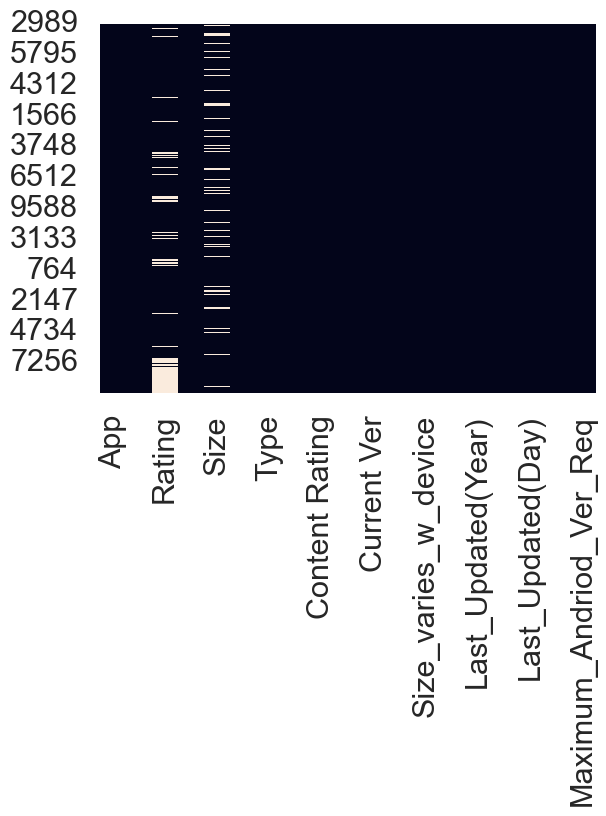

In [919]:
sns.heatmap(df.isna(),cbar=False)
plt.show()

Here Rating has the maximum null values, Size do have more null values but those were just absence of exact size,the size varies with device

We will not fill missing Rating values with the mean or median, as this could introduce bias during EDA.

Null ratings may indicate:

Random missing data (MCAR)

New apps that haven’t received ratings yet

Apps with low user interest, resulting in few or no ratings

**Let’s create a separate column for unrated apps that gives True for NaN values, as these are most likely unrated apps.**

In [920]:
df['Unrated App']= df['Rating'].isna()

In [921]:
df.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_andriod_versions,Maximum_Andriod_Ver_Req,Unrated App
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1,False,Not Mentioned,2018,5,23,True,4.1,False
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,3.2,2.2,False,Not Mentioned,2013,12,17,True,2.2,False
2705,SnipSnap Coupon App,SHOPPING,4.2,9975.0,18000000.0,1000000.0,Free,0.0,Everyone,Shopping,1.4,4.3,False,Not Mentioned,2018,1,22,True,4.3,False


In [922]:
##Filtering Rows with "Rating" == " NaN"
df[df['Rating'].isna()].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_andriod_versions,Maximum_Andriod_Ver_Req,Unrated App
3621,Voice Tables - no internet,PARENTING,NaN,970.0,71000000.0,100000.0,Free,0.0,Everyone,Parenting,2.0,4.0.3,False,Not Mentioned,2018,5,28,True,4.0.3,True
10808,lesparticuliers.fr,LIFESTYLE,NaN,96.0,1000000.0,50000.0,Free,0.0,Everyone,Lifestyle,1.5,2.3,False,Not Mentioned,2014,11,25,True,2.3,True
10818,Gold Quote - Gold.fr,FINANCE,NaN,96.0,1500000.0,10000.0,Free,0.0,Everyone,Finance,2.3,2.2,False,Not Mentioned,2016,5,19,True,2.2,True
9834,Recettes Faciles et Rapides,FOOD_AND_DRINK,NaN,95.0,12000000.0,50000.0,Free,0.0,Everyone,Food & Drink,3.0.1,2.3,False,Not Mentioned,2018,1,6,True,2.3,True
1177,Easy and Fast Recipes,FOOD_AND_DRINK,NaN,95.0,12000000.0,50000.0,Free,0.0,Everyone,Food & Drink,3.0.1,2.3,False,Not Mentioned,2018,1,6,True,2.3,True


**ALL UNRATED APP ARE NOW FLAG AS TRUE**

***

## Bivariate Chart for Numerical Variable

In [923]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_andriod_versions,Maximum_Andriod_Ver_Req,Unrated App
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1,False,Not Mentioned,2018,5,23,True,4.1,False
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,3.2,2.2,False,Not Mentioned,2013,12,17,True,2.2,False


## Does price affect Rating?

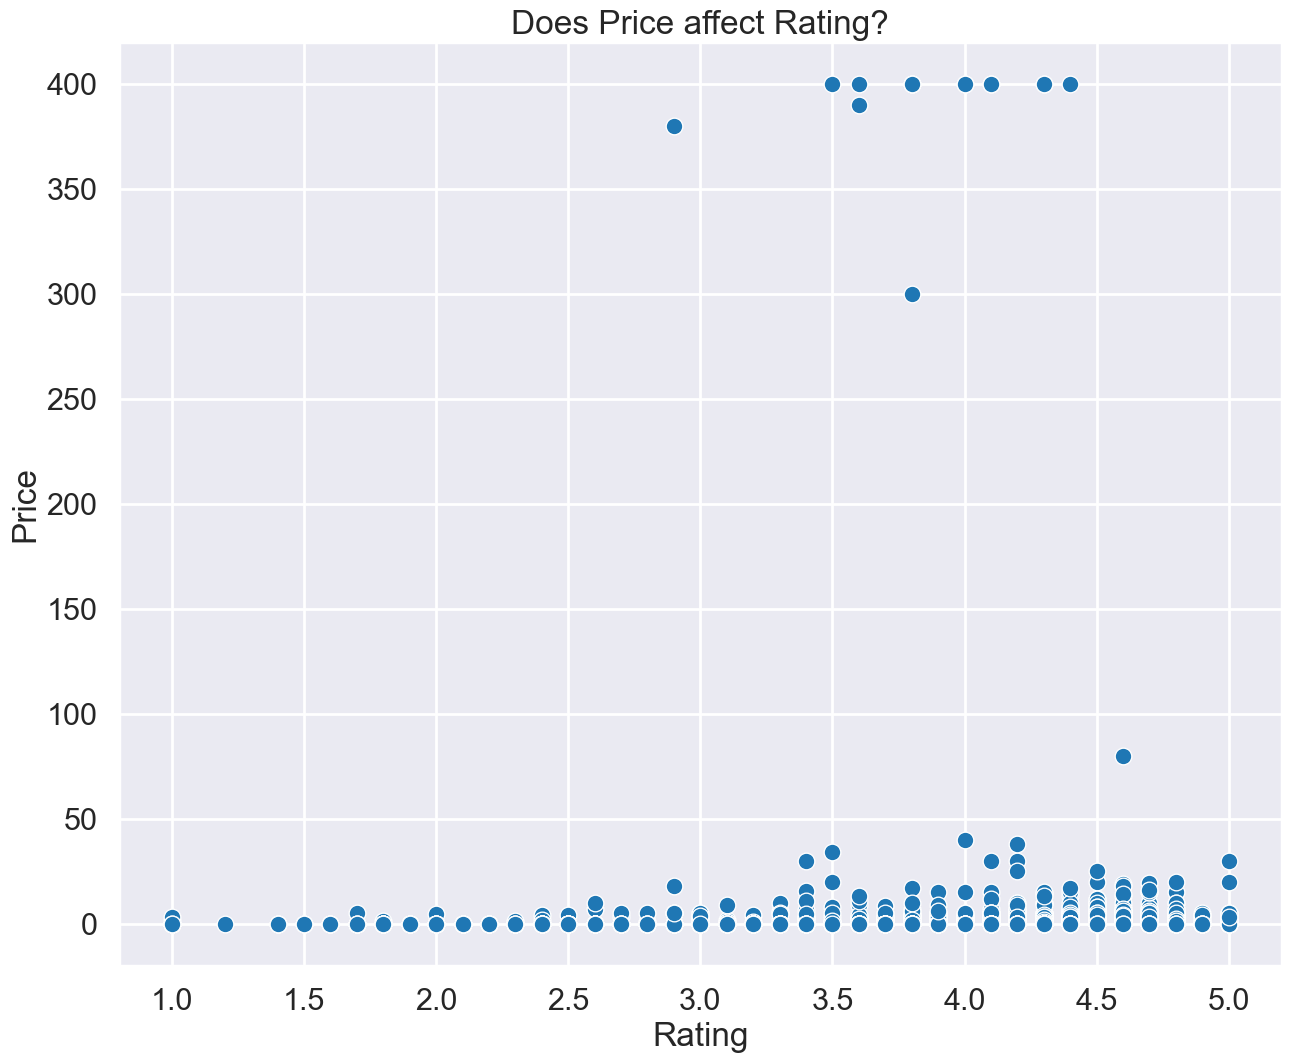

In [924]:
plt.figure(figsize=(15,12))
sns.scatterplot(data=df,x='Rating',y='Price($)')
plt.title('Does Price affect Rating?')
plt.xlabel('Rating')
plt.ylabel('Price')
plt.show()

## Observation

- Most apps cluster at a low price range (0–20) regardless of their rating.

- High-priced apps (above 100) are very few and appear as outliers.

- There doesn’t seem to be a clear correlation between Price and Rating — highly rated apps exist at both low and high prices.

- A large number of apps have ratings between 4 and 5 with a price near 0, suggesting that free or low-cost apps dominate.

- Some extreme price points (e.g., 300–400) do not correspond to higher ratings, indicating price doesn’t guarantee higher rating.

***

<Axes: xlabel='Rating', ylabel='Installs'>

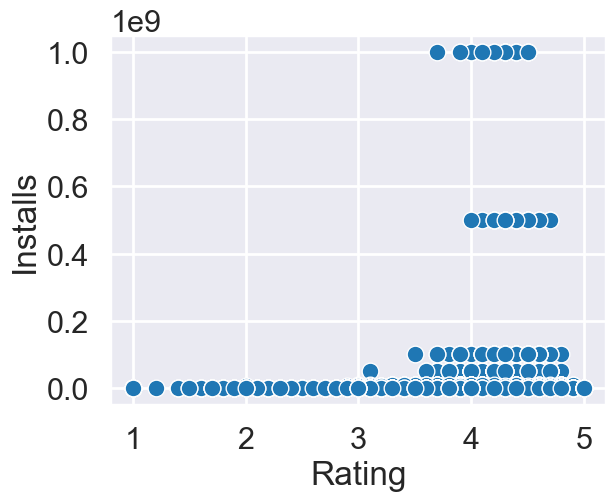

In [925]:
sns.scatterplot(data=df,x='Rating',y='Installs')

## Observation


-Positive trend: There is a general trend where apps with higher ratings tend to have more installs, although it is not perfectly linear.

-High install clusters:

-A noticeable cluster of apps around 4.0–4.5 rating have very high installs (around 0.5–1 billion).

-Another cluster of apps with similar high ratings (4.0–4.5) have moderate installs (around 0.1–0.5 billion).

-Low-rated apps: Apps with ratings below 3.0 generally have very low installs.

***

In [926]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price($)', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver',
       'Size_varies_w_device', 'sub_genre', 'Last_Updated(Year)',
       'Last_Updated(Month))', 'Last_Updated(Day)',
       'Support_all_newer_andriod_versions', 'Maximum_Andriod_Ver_Req',
       'Unrated App'],
      dtype='object')

**GETTING NUMERICAL COLUMNS**

In [927]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)


Index(['Rating', 'Reviews', 'Size', 'Installs', 'Price($)'], dtype='object')


## Single Numerical variable

## COUNT OF NUMERICAL COLUMNS

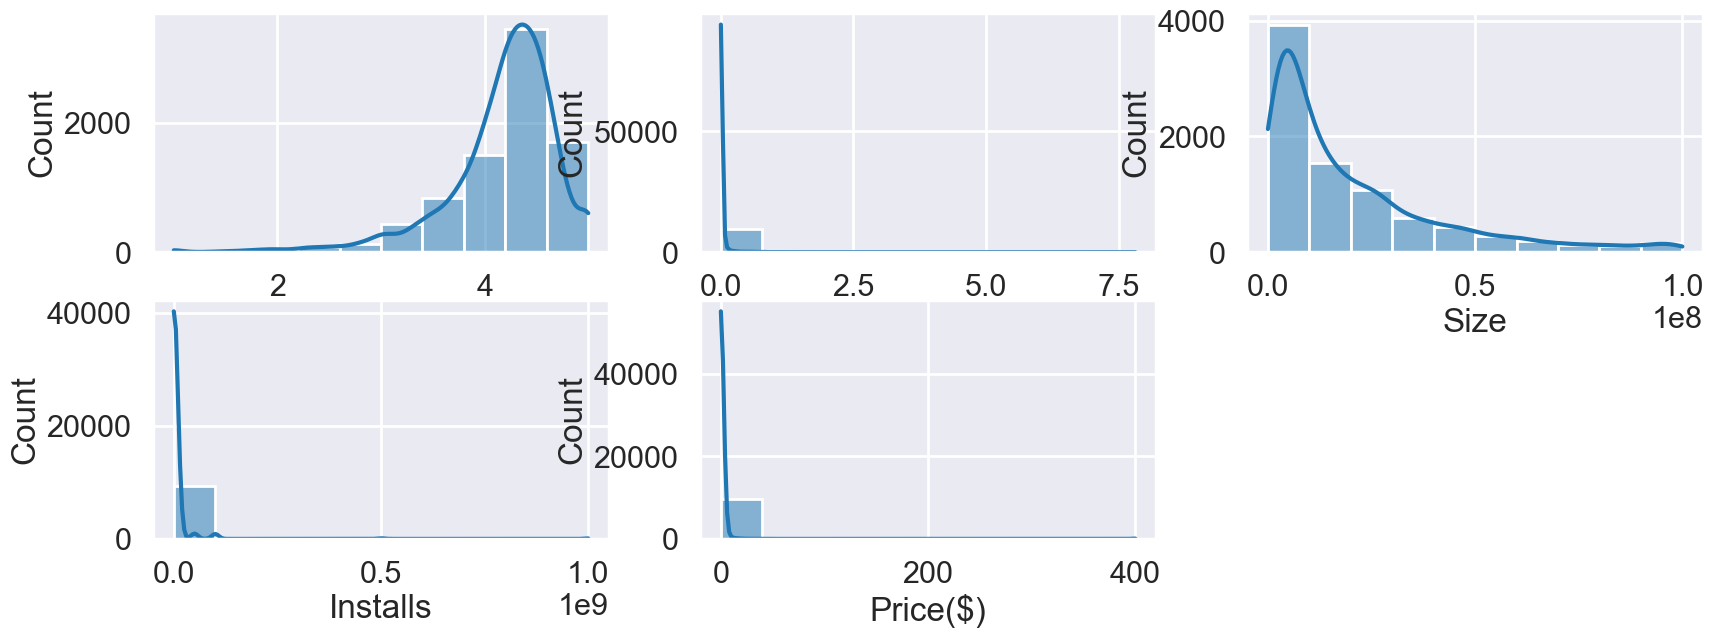

In [928]:
## hist plot

plt.figure(figsize=(20,18))

for i ,cols in enumerate(numerical_cols,1):
    plt.subplot(5,3,i)
    sns.histplot(df[cols],bins=10, kde=True,)


plt.show()

## Observation


Most apps are highly rated, free, and lightweight, but only a few have massive reviews or installs.

Outliers exist in reviews, installs, and price, which could affect statistical analyses like mean or standard deviation.

Data transformations like log transformation may be helpful for skewed columns (Reviews, Installs, Price) for modeling purposes.

***

## Relation among numerical variables

In [929]:
#Heatmap

corr = df[['Rating','Reviews','Size','Installs','Price($)']].corr()

In [930]:
corr

,Rating,Reviews,Size,Installs,Price($)
Rating,1.000000,0.055104,0.063449,0.040187,-0.021130
Reviews,0.055104,1.000000,0.179389,0.625155,-0.007597
Size,0.063449,0.179389,1.000000,0.134285,-0.022426
Installs,0.040187,0.625155,0.134285,1.000000,-0.009407
Price($),-0.021130,-0.007597,-0.022426,-0.009407,1.000000


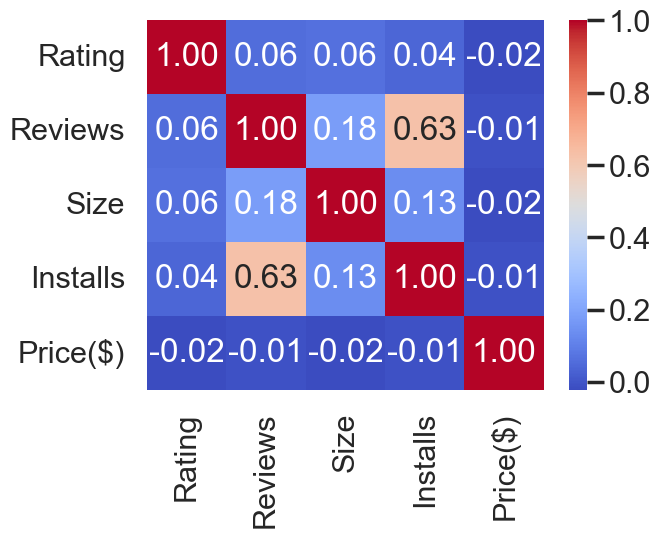

In [931]:
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm')
plt.show()

## Observations

Rating, Price, Size have almost no significant correlation with each other or with installs/reviews.

Reviews and Installs are the only pair with a meaningful correlation, indicating that more popular apps naturally get more reviews.

***

## Univariate (single categorical variable)

In [932]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_andriod_versions,Maximum_Andriod_Ver_Req,Unrated App
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1,False,Not Mentioned,2018,5,23,True,4.1,False
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,3.2,2.2,False,Not Mentioned,2013,12,17,True,2.2,False


In [933]:
df['Maximum_Andriod_Ver_Req'].unique()

array(['4.1', '2.2', '4.3', '5.0', '2.1', '4.0.3', 'Varies with device',
       '2.3', '4.2', '4.0', '4.4', '7.0', '1.6', '2.3.3', '3.0', '1.5',
       '5.1', '6.0', '3.1', '2.0', '7.1.1', '3.2', '4.4W', '7.1', '2.0.1',
       '8.0', '1.0', 'Unknown'], dtype=object)

**Getting Categorical Column**

In [934]:
categorical_col = df.select_dtypes(include= 'object').columns

In [935]:
categorical_col

Index(['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver',
       'Android Ver', 'sub_genre', 'Maximum_Andriod_Ver_Req'],
      dtype='object')

In [936]:
len(categorical_col)

9

## Count of Categorical Column

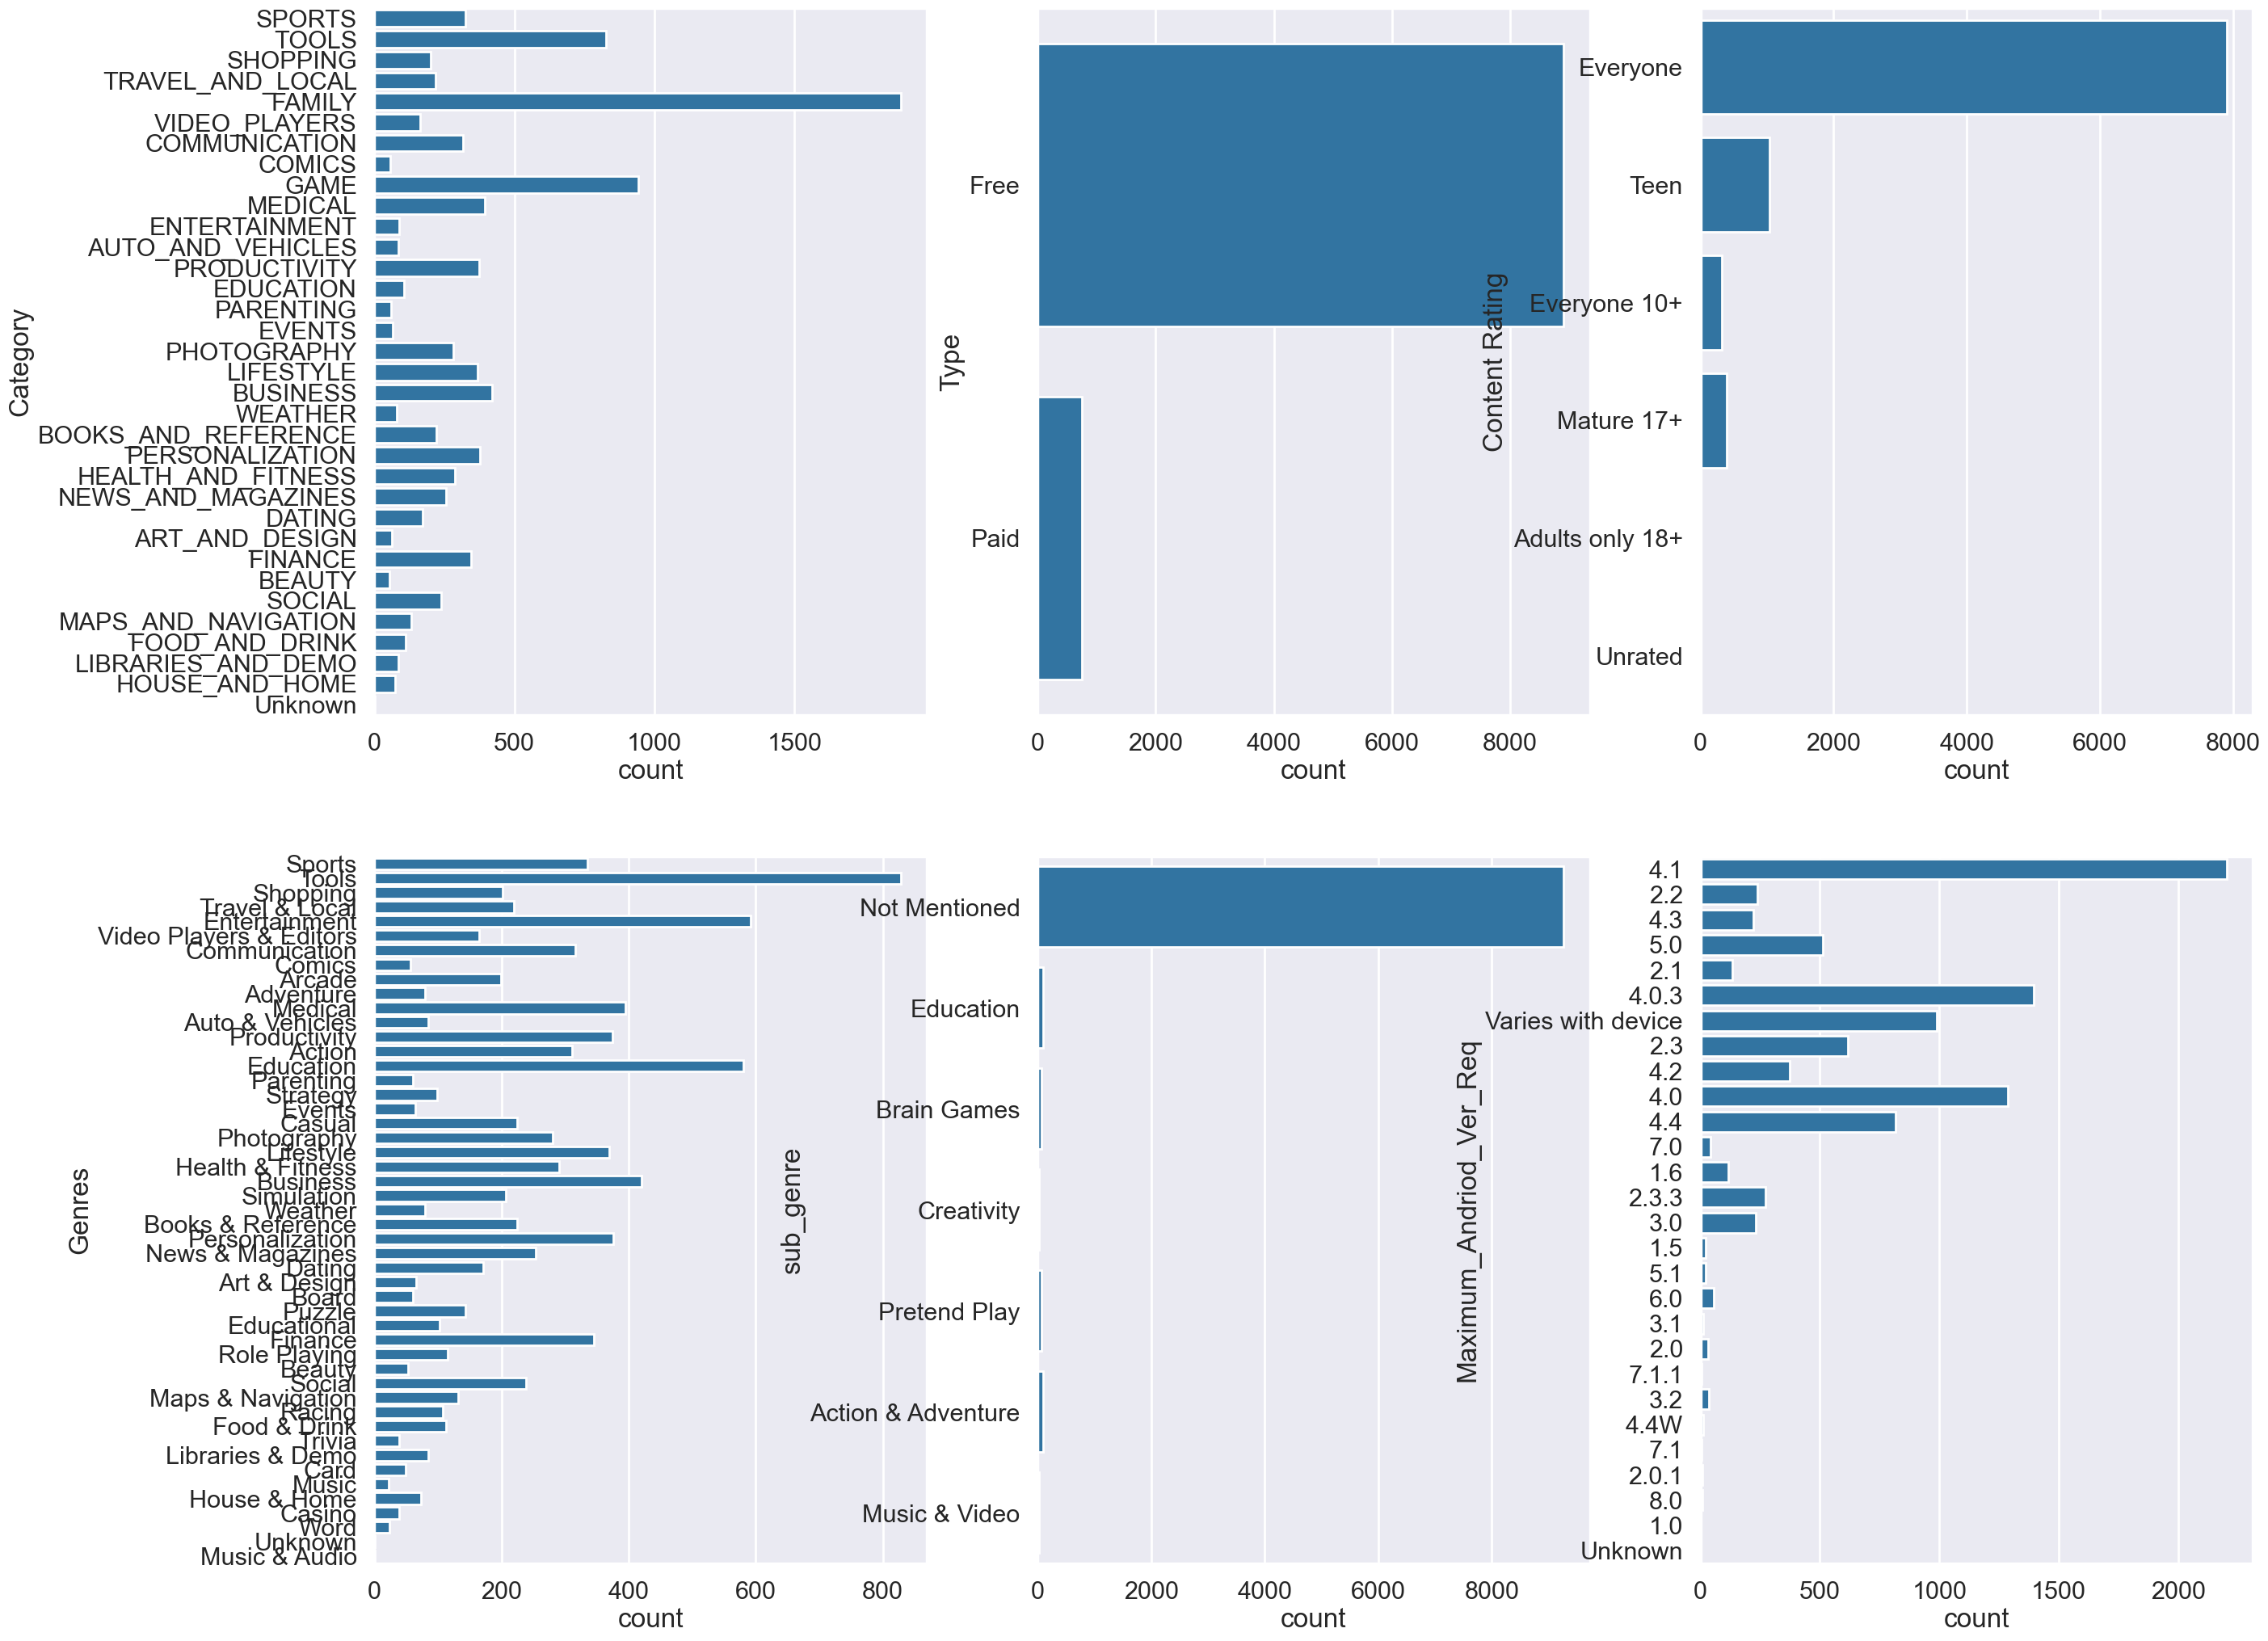

In [937]:

plt.figure(figsize=(30,25))
cat=['Category','Type','Content Rating','Genres','sub_genre','Maximum_Andriod_Ver_Req']

for i, value in enumerate(cat,1):
    plt.subplot(2,3,i)
    sns.countplot(df[value])
plt.show()

## Observation

The dataset is dominated by free apps targeting general audiences.

Popular Category are Games,Entertainment,Tools, Education etc

Some columns, especially sub-genre, have missing data

The Android version requirement shows a focus on modern devices, but there is still backward compatibility for some apps.

***

# Bivariate (two categorical variables)

## Popular Category According too Free and Paid APP

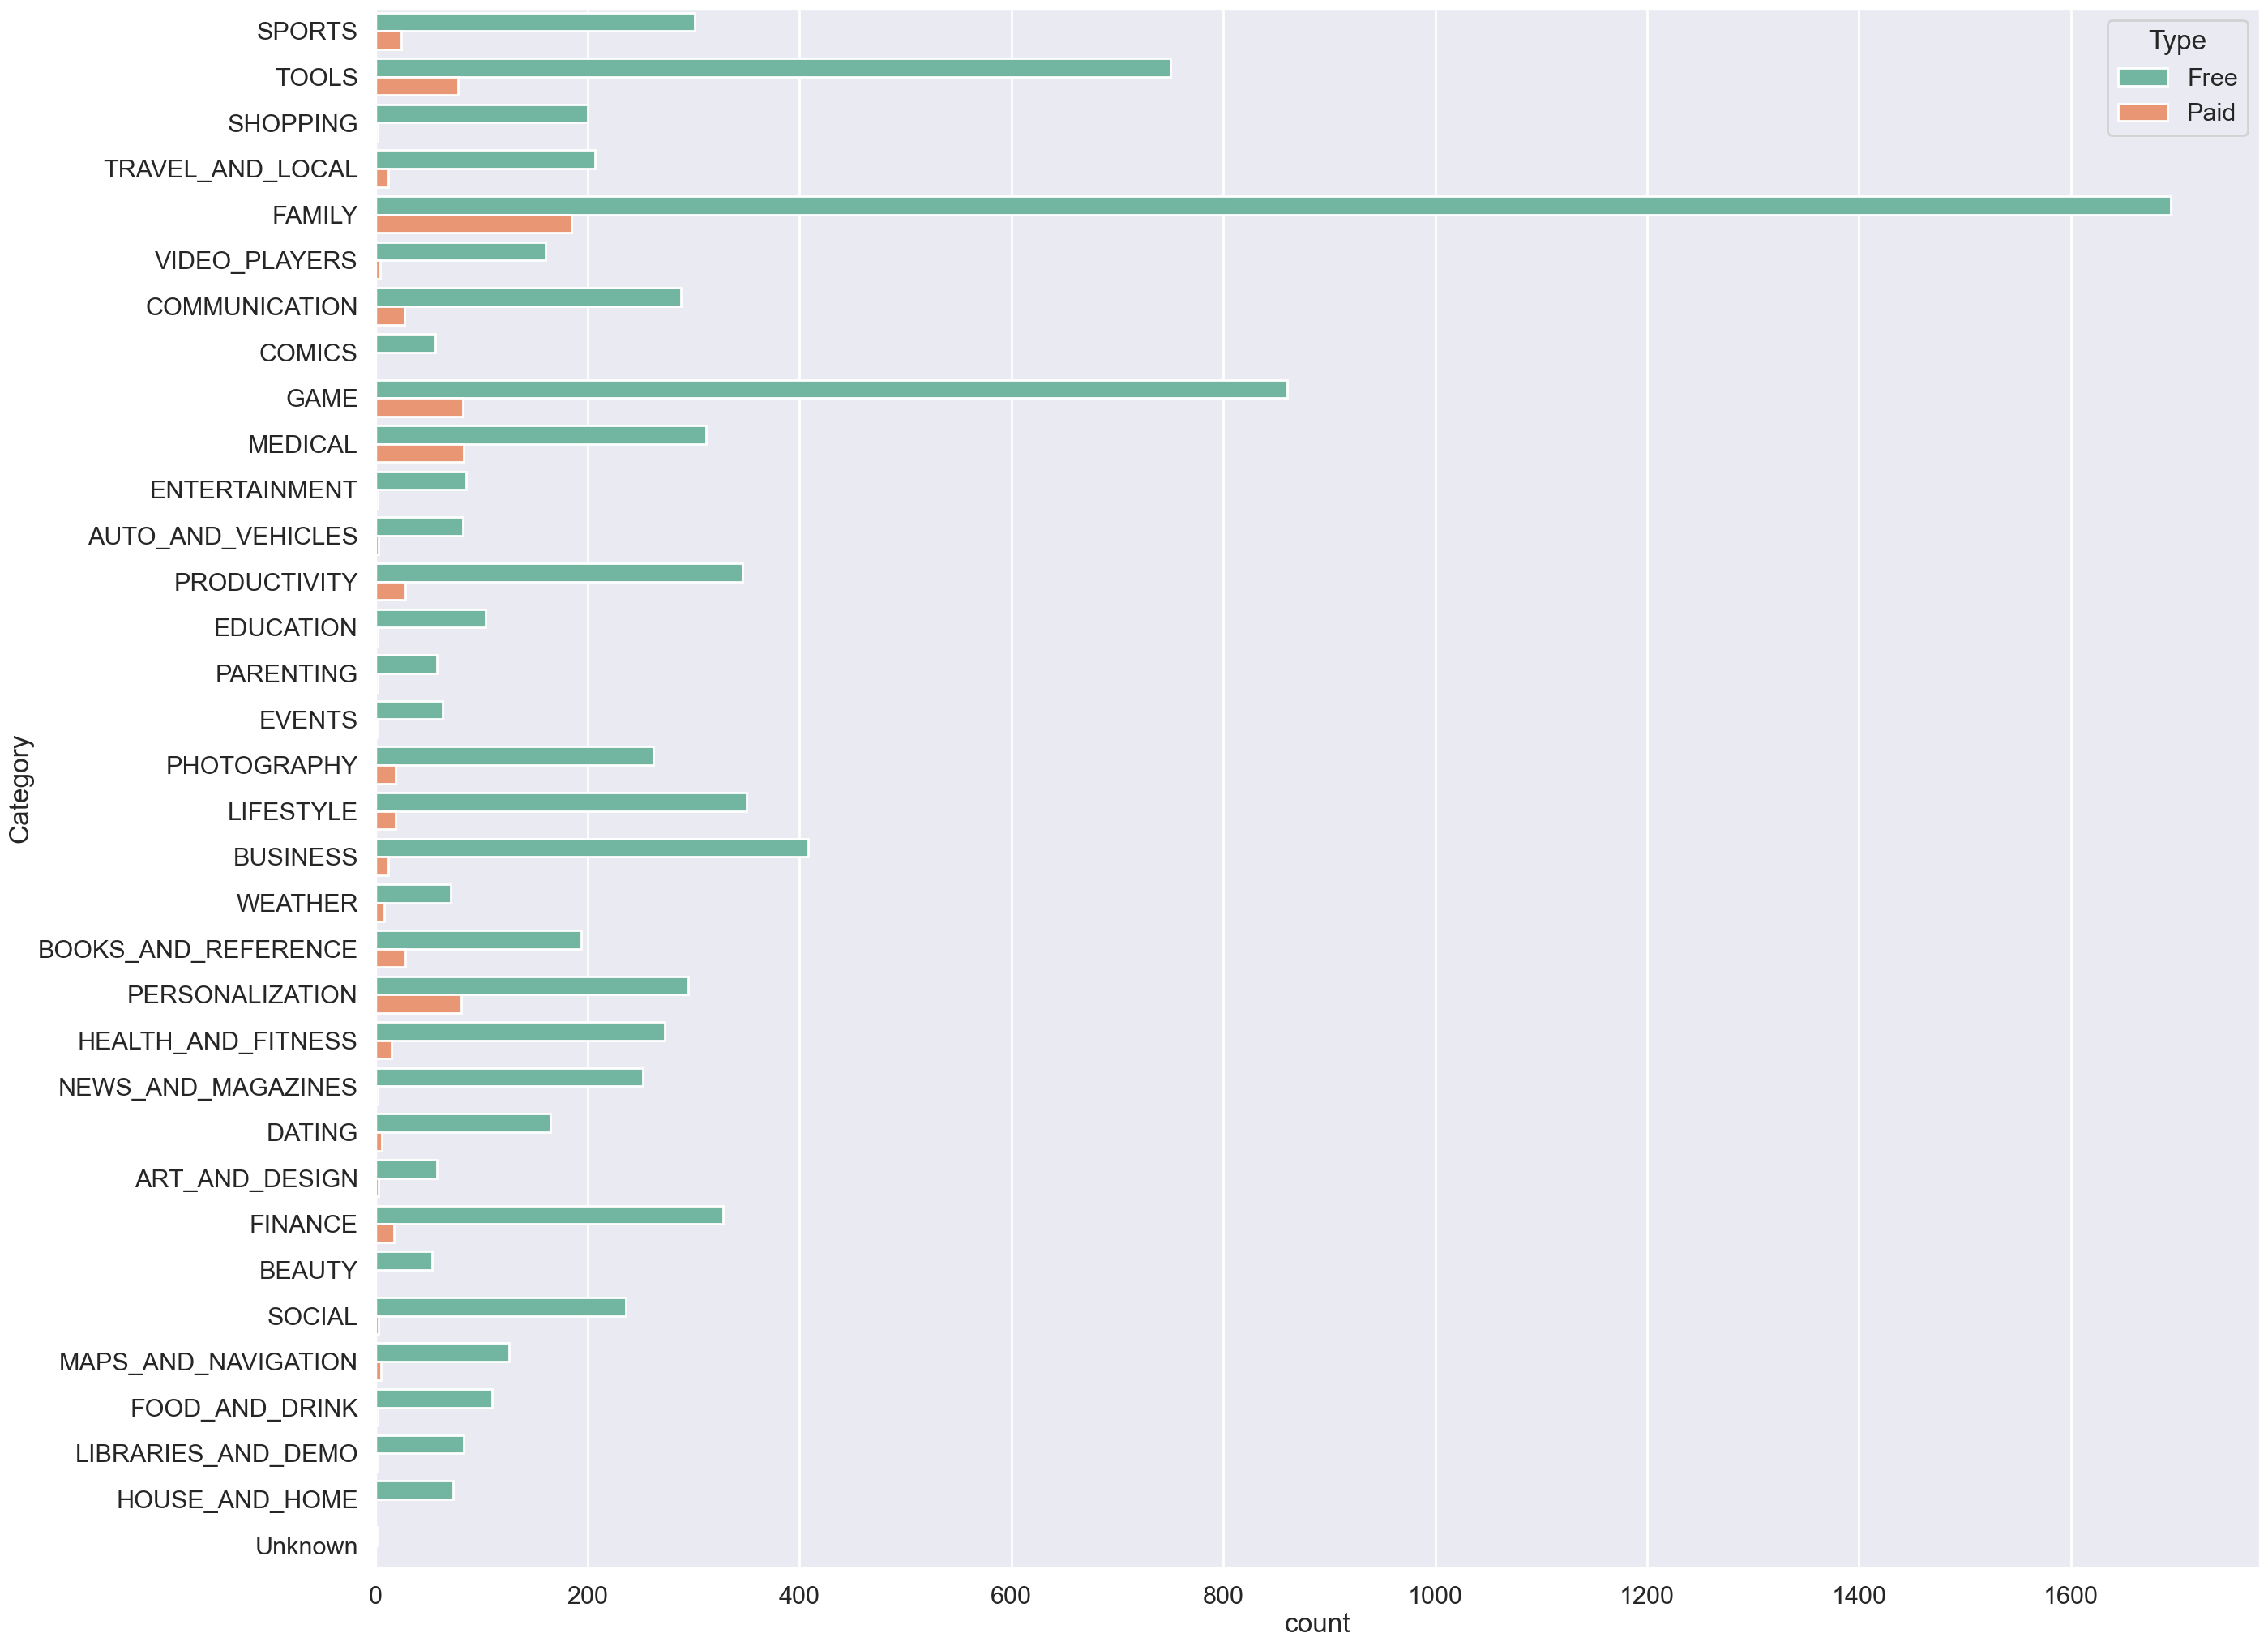

In [938]:

#Count plot with hue
plt.figure(figsize=(30,25))
sns.countplot(data=df,y='Category', hue = 'Type', palette='Set2')
plt.show()

***

## NUMBER OF FREE AND PAID APP IN EACH CATEGORY

In [939]:
# Heatmap of two categorical variable
ct=pd.crosstab(df['Category'],df['Type'])
ct.sort_values(by='Free',ascending=False)

Type,Free,Paid
Category,,
FAMILY,1694,185
GAME,860,82
TOOLS,750,78
BUSINESS,408,12
LIFESTYLE,350,19
PRODUCTIVITY,346,28
FINANCE,328,17
MEDICAL,312,83
SPORTS,301,24


***

# Univariate (one categorical → numeric)

In [940]:
df.head(1)

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_andriod_versions,Maximum_Andriod_Ver_Req,Unrated App
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1,False,Not Mentioned,2018,5,23,True,4.1,False


## Average Price in Each Category

C:\Users\user\AppData\Local\Temp\ipykernel_16348\3237722200.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,y='Category',x='Price($)',palette='Set1')


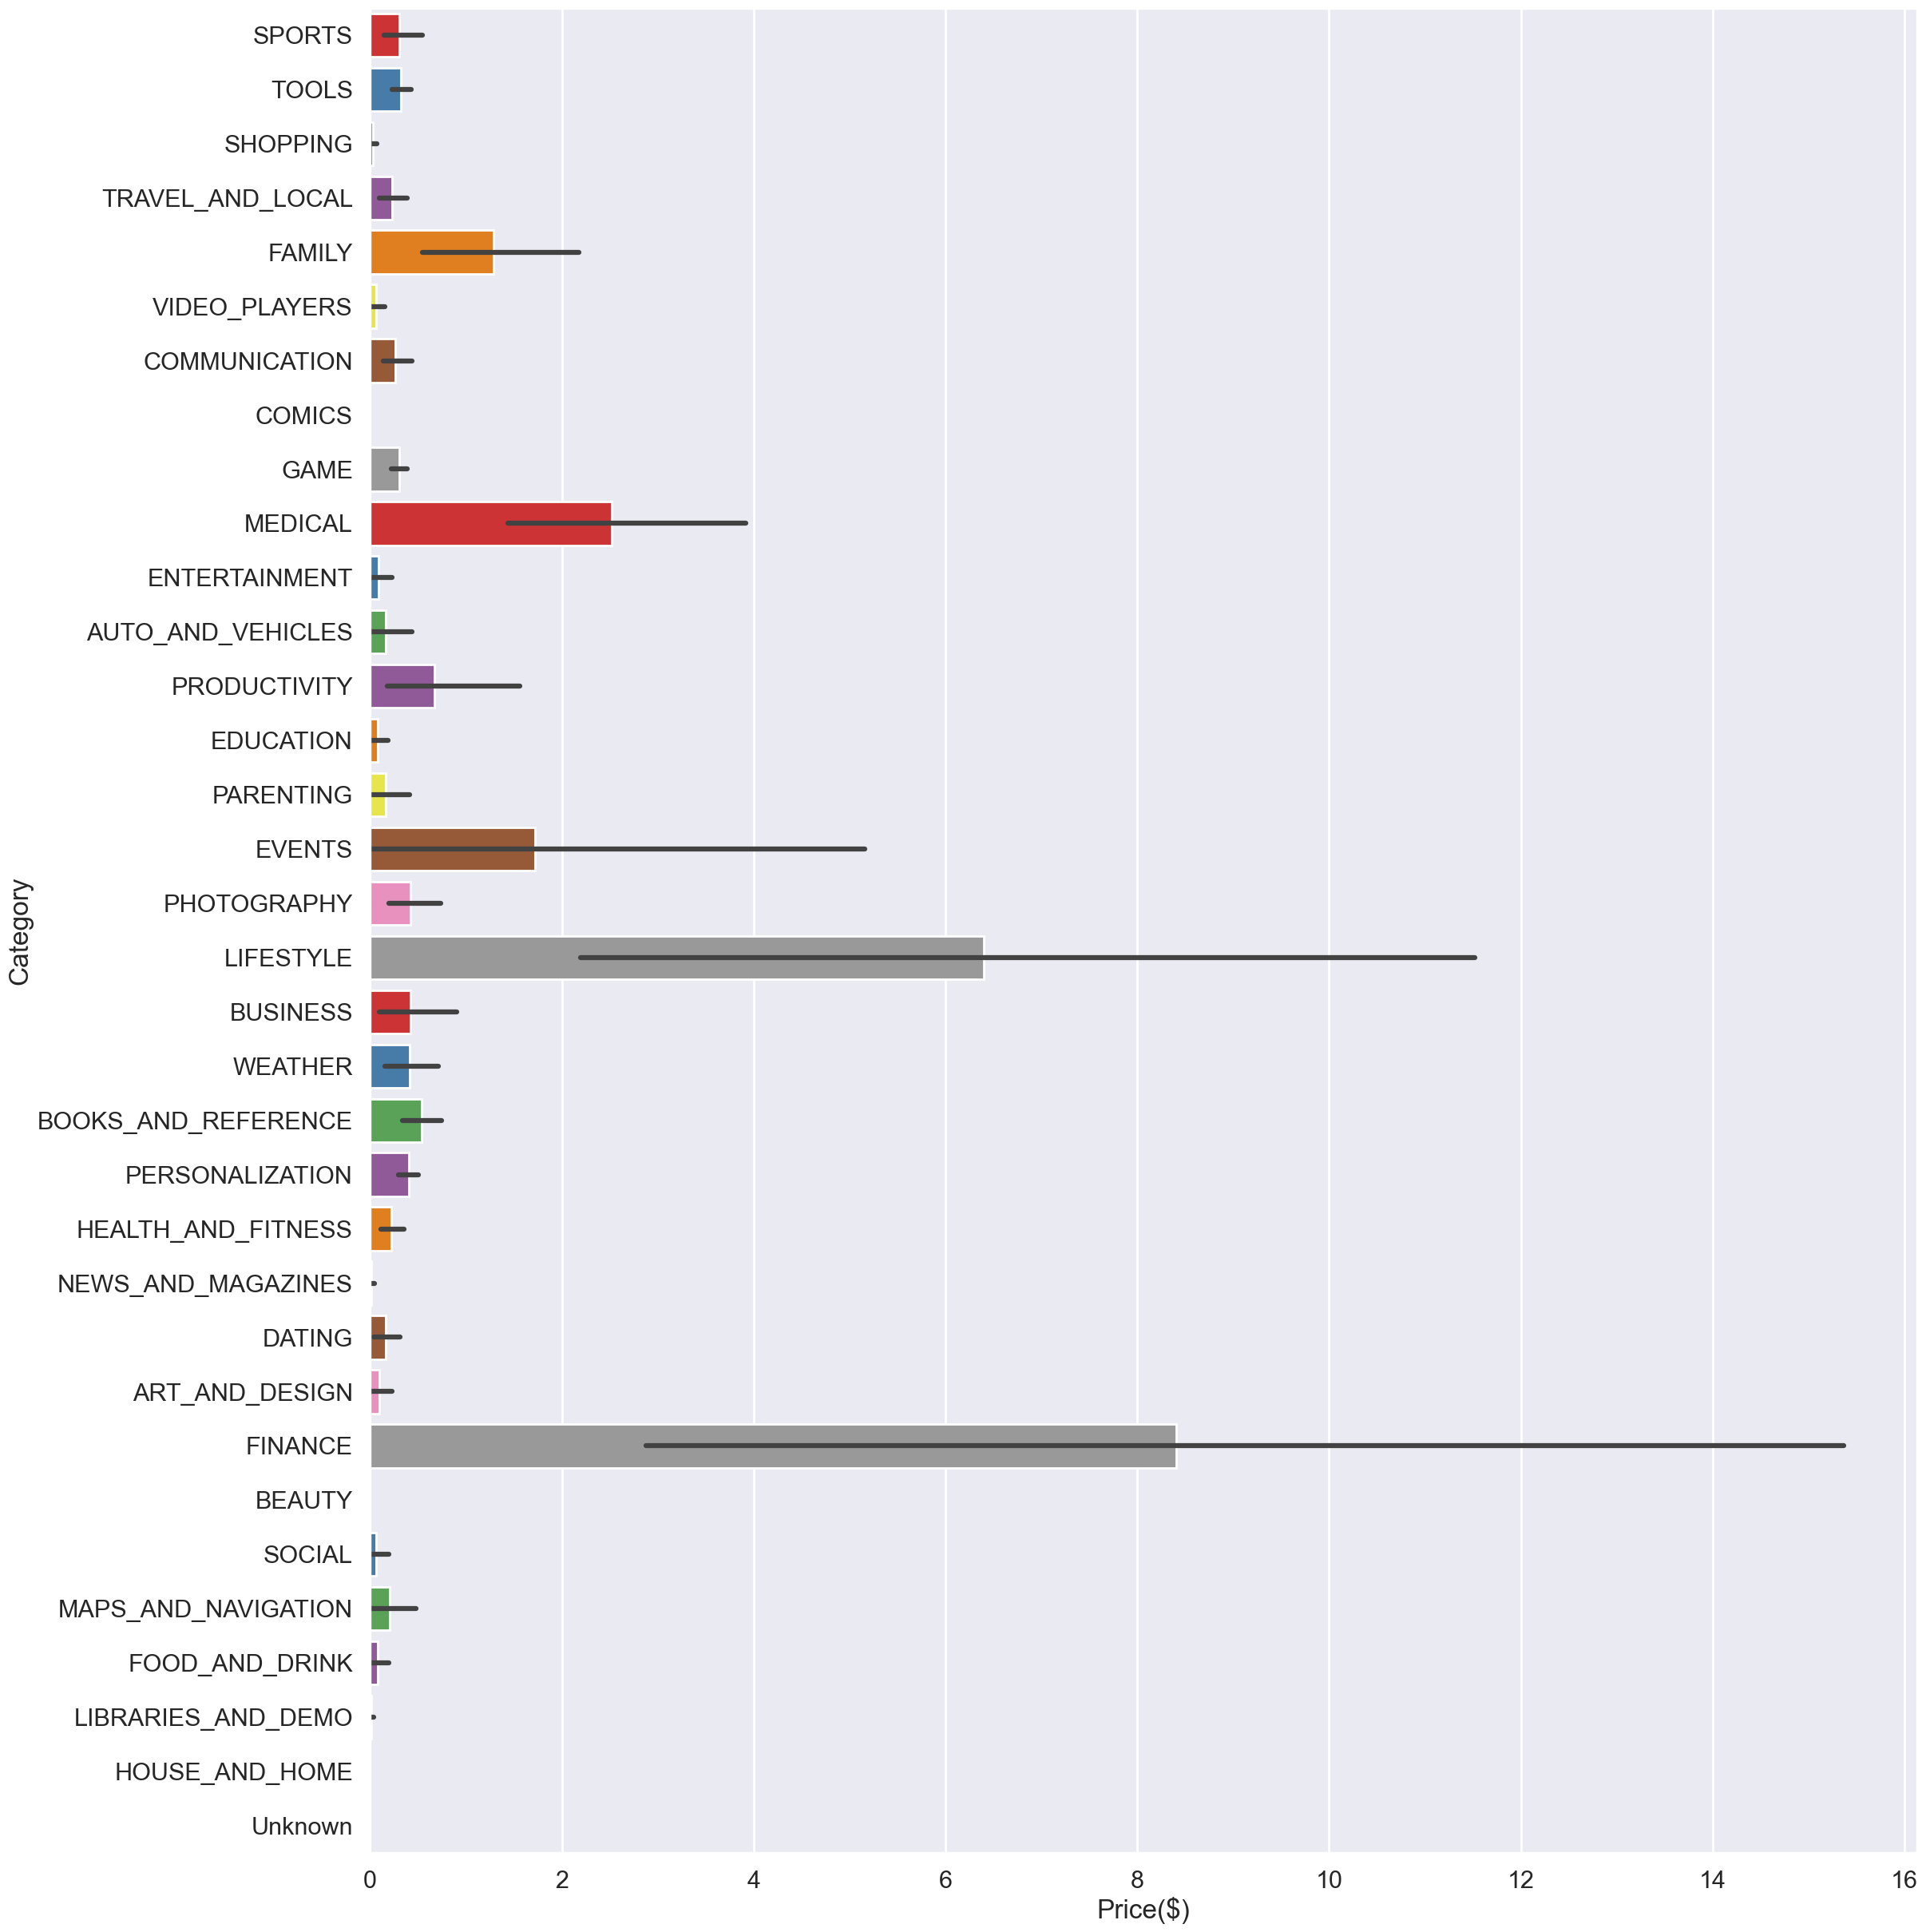

In [941]:
# bar plot
plt.figure(figsize=(25,30))
sns.barplot(data=df,y='Category',x='Price($)',palette='Set1')
plt.show()

***

## BOX PLOT FOR PRICE

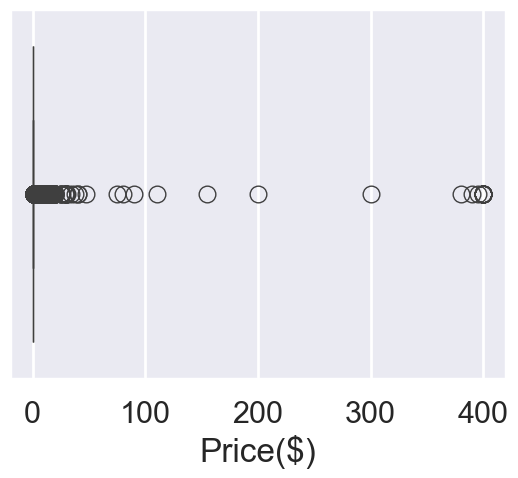

In [942]:
#box plot

sns.boxplot(data=df,x='Price($)')
plt.show()

## Observation

Most of the app prices are clustered around $0–$10, showing that the majority of apps are either free or very cheap.

There are many outliers spread across higher price ranges, going all the way up to $400.

The distribution is highly right-skewed (long tail towards expensive apps).

Median and IQR are very close to the lower end, confirming that expensive apps are rare.

***

In [943]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_andriod_versions,Maximum_Andriod_Ver_Req,Unrated App
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1,False,Not Mentioned,2018,5,23,True,4.1,False
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,3.2,2.2,False,Not Mentioned,2013,12,17,True,2.2,False
2705,SnipSnap Coupon App,SHOPPING,4.2,9975.0,18000000.0,1000000.0,Free,0.0,Everyone,Shopping,1.4,4.3,False,Not Mentioned,2018,1,22,True,4.3,False
3229,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971.0,22000000.0,500000.0,Free,0.0,Teen,Travel & Local,1.28.1,5.0,False,Not Mentioned,2018,8,6,True,5.0,False
3049,US Open Tennis Championships 2018,SPORTS,4.0,9971.0,33000000.0,1000000.0,Free,0.0,Everyone,Sports,7.1,5.0,False,Not Mentioned,2018,6,5,True,5.0,False


## TOP INSTALLS APP

In [944]:
Top_Download_APP = df.sort_values(by='Installs',ascending=False).head()

In [945]:
Top_Download_APP

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_andriod_versions,Maximum_Andriod_Ver_Req,Unrated App
411,Google Chrome: Fast & Secure,COMMUNICATION,4.3,9643041.0,NaN,1.000000e+09,Free,0.0,Everyone,Communication,Varies with device,Varies with device,True,Not Mentioned,2018,8,1,False,Varies with device,False
5856,Google Play Games,FAMILY,4.3,7168735.0,NaN,1.000000e+09,Free,0.0,Teen,Entertainment,Varies with device,Varies with device,True,Not Mentioned,2018,7,16,False,Varies with device,False
3665,YouTube,VIDEO_PLAYERS,4.3,25655305.0,NaN,1.000000e+09,Free,0.0,Teen,Video Players & Editors,Varies with device,Varies with device,True,Not Mentioned,2018,8,2,False,Varies with device,False
2884,Google Photos,PHOTOGRAPHY,4.5,10859051.0,NaN,1.000000e+09,Free,0.0,Everyone,Photography,Varies with device,Varies with device,True,Not Mentioned,2018,8,6,False,Varies with device,False
464,Hangouts,COMMUNICATION,4.0,3419513.0,NaN,1.000000e+09,Free,0.0,Everyone,Communication,Varies with device,Varies with device,True,Not Mentioned,2018,7,21,False,Varies with device,False


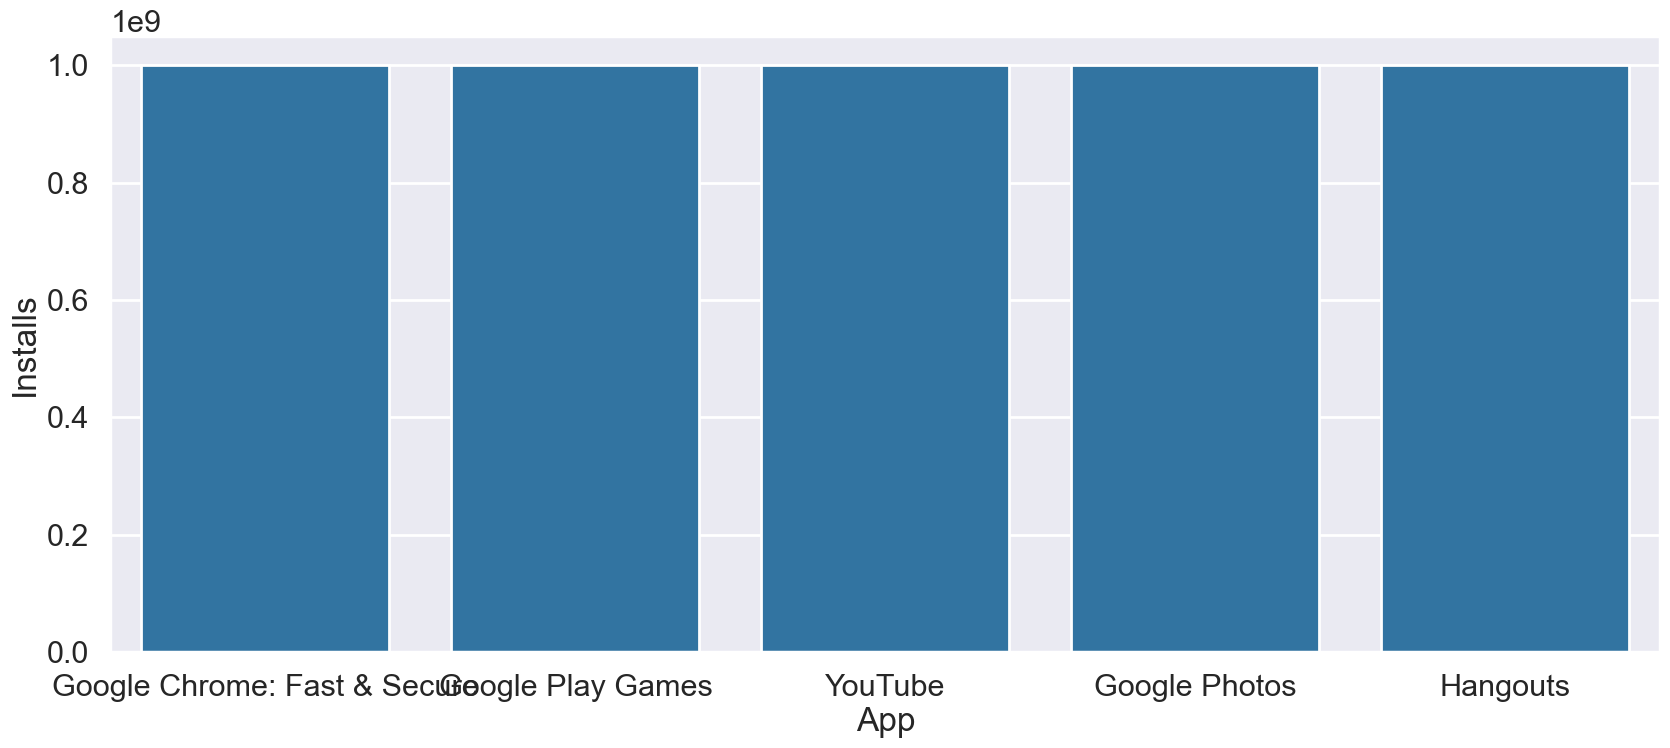

In [946]:
plt.figure(figsize=(20,8))
sns.barplot(data=Top_Download_APP,x='App',y='Installs')
plt.show()

## Observation

Google Play Games, Maps, Google, Facebook and Google + are the Top 5 downloads

***

## MOST POPULAR CATEGORY

In [947]:
Category = df['Category'].value_counts()

In [948]:
Top_Category= pd.DataFrame(Category.sort_values(ascending=False))

In [949]:
Top_Category

,count
Category,
FAMILY,1879
GAME,942
TOOLS,828
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


<Axes: xlabel='Category', ylabel='count'>

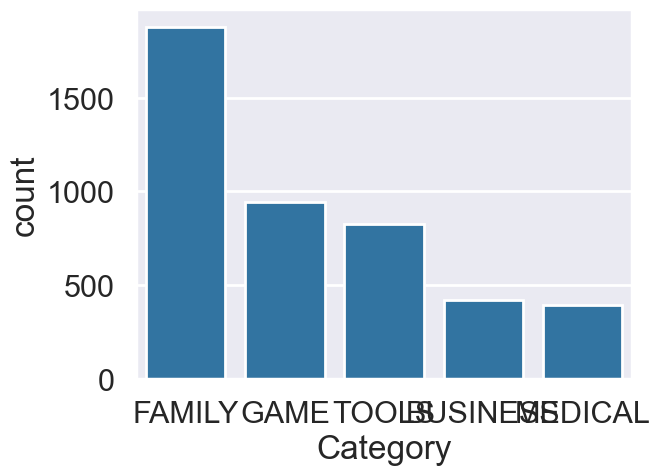

In [950]:
sns.barplot(data=Top_Category[:5],x='Category',y='count')

***


## Which Category has largest number of installations??


In [951]:
Most_Installed_Category=df.groupby('Category')['Installs'].sum().sort_values(ascending=False).reset_index().head()

In [952]:
Most_Installed_Category

,Category,Installs
0,GAME,1.337792e+10
1,COMMUNICATION,1.103828e+10
2,TOOLS,8.002772e+09
3,FAMILY,6.237643e+09
4,PRODUCTIVITY,5.793091e+09


<Axes: xlabel='Category', ylabel='Installs'>

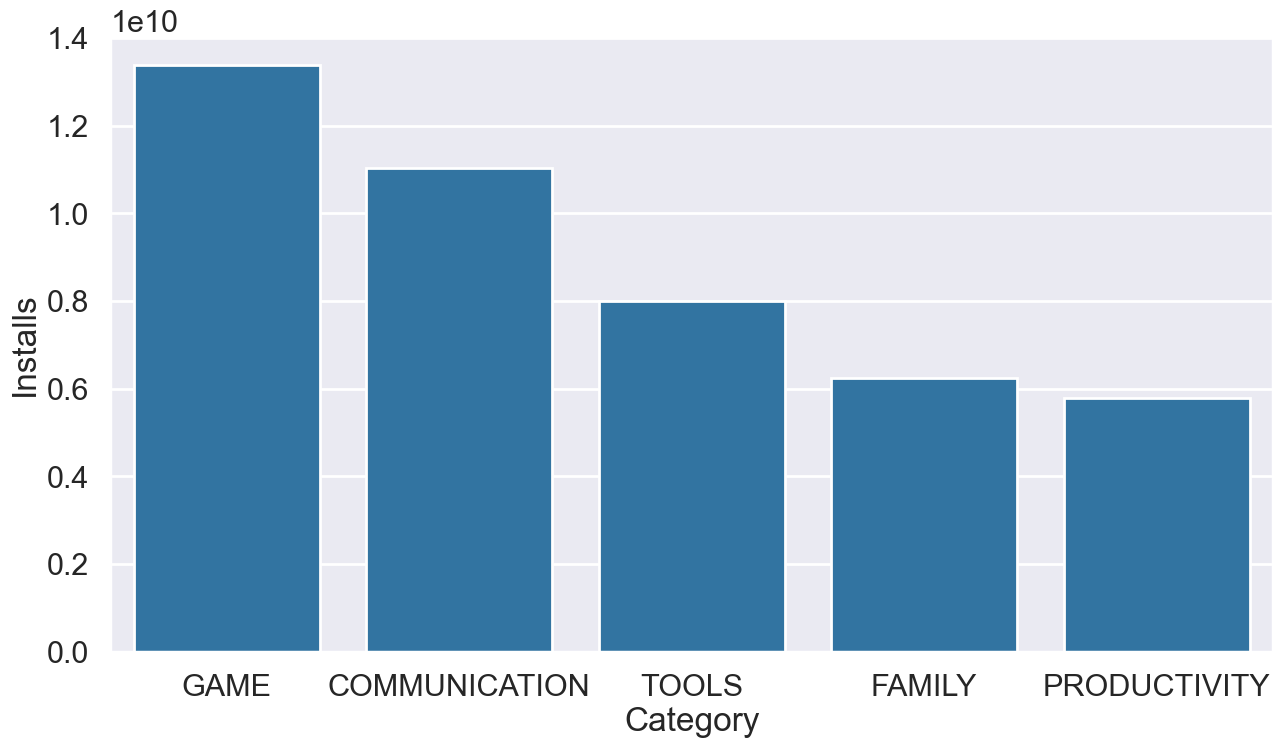

In [977]:
plt.figure(figsize=(15,8))
sns.barplot(data=Most_Installed_Category,x='Category',y='Installs')

***

## What are the Top 5 most installed Apps in Each popular Categories ??


In [954]:
df1= df.groupby(['Category','App'])['Installs'].sum().reset_index()

In [955]:
df1

,Category,App,Installs
0,ART_AND_DESIGN,350 Diy Room Decor Ideas,10000.0
1,ART_AND_DESIGN,3D Color Pixel by Number - Sandbox Art Coloring,100000.0
2,ART_AND_DESIGN,AJ Styles HD Wallpapers,5000.0
3,ART_AND_DESIGN,AJ Styles Wallpaper 2018 - AJ Styles HD Wallpaper,1000.0
4,ART_AND_DESIGN,Ai illustrator viewer,100000.0
...,...,...,...
9655,WEATHER,Yahoo Weather,10000000.0
9656,WEATHER,Yahoo! Weather for SH Forecast for understandi...,1000000.0
9657,WEATHER,Yandex.Weather,10000000.0
9658,WEATHER,weather - weather forecast,1000000.0


In [956]:
Top_Category2 = Top_Category.head().index

In [957]:
Top_Category2

Index(['FAMILY', 'GAME', 'TOOLS', 'BUSINESS', 'MEDICAL'], dtype='object', name='Category')

In [958]:
df1=df1.sort_values('Installs',ascending=False)

In [959]:
df1

,Category,App,Installs
8835,TOOLS,Google,1.000000e+09
1142,COMMUNICATION,Skype - free IM & video calls,1.000000e+09
9567,VIDEO_PLAYERS,YouTube,1.000000e+09
7917,SOCIAL,Instagram,1.000000e+09
2651,FAMILY,Google Play Games,1.000000e+09
...,...,...,...
5577,LIFESTYLE,I'm Rich/Eu sou Rico/أنا غني/我很有錢,0.000000e+00
6018,MEDICAL,EP Cook Book,0.000000e+00
6469,NEWS_AND_MAGAZINES,Sweden Newspapers,0.000000e+00
7961,SOCIAL,Pekalongan CJ,0.000000e+00


In [960]:
Top_Category2

Index(['FAMILY', 'GAME', 'TOOLS', 'BUSINESS', 'MEDICAL'], dtype='object', name='Category')

In [961]:
for i, col in enumerate(Top_Category2):
    df2 = df1[df1.Category==col]
    df3= df2.head(5)
df3

,Category,App,Installs
5923,MEDICAL,Blood Pressure,5000000.0
6119,MEDICAL,My Calendar - Period Tracker,5000000.0
6254,MEDICAL,mySugr: the blood sugar tracker made just for you,1000000.0
6170,MEDICAL,Pregnancy Week By Week,1000000.0
5963,MEDICAL,CareZone,1000000.0


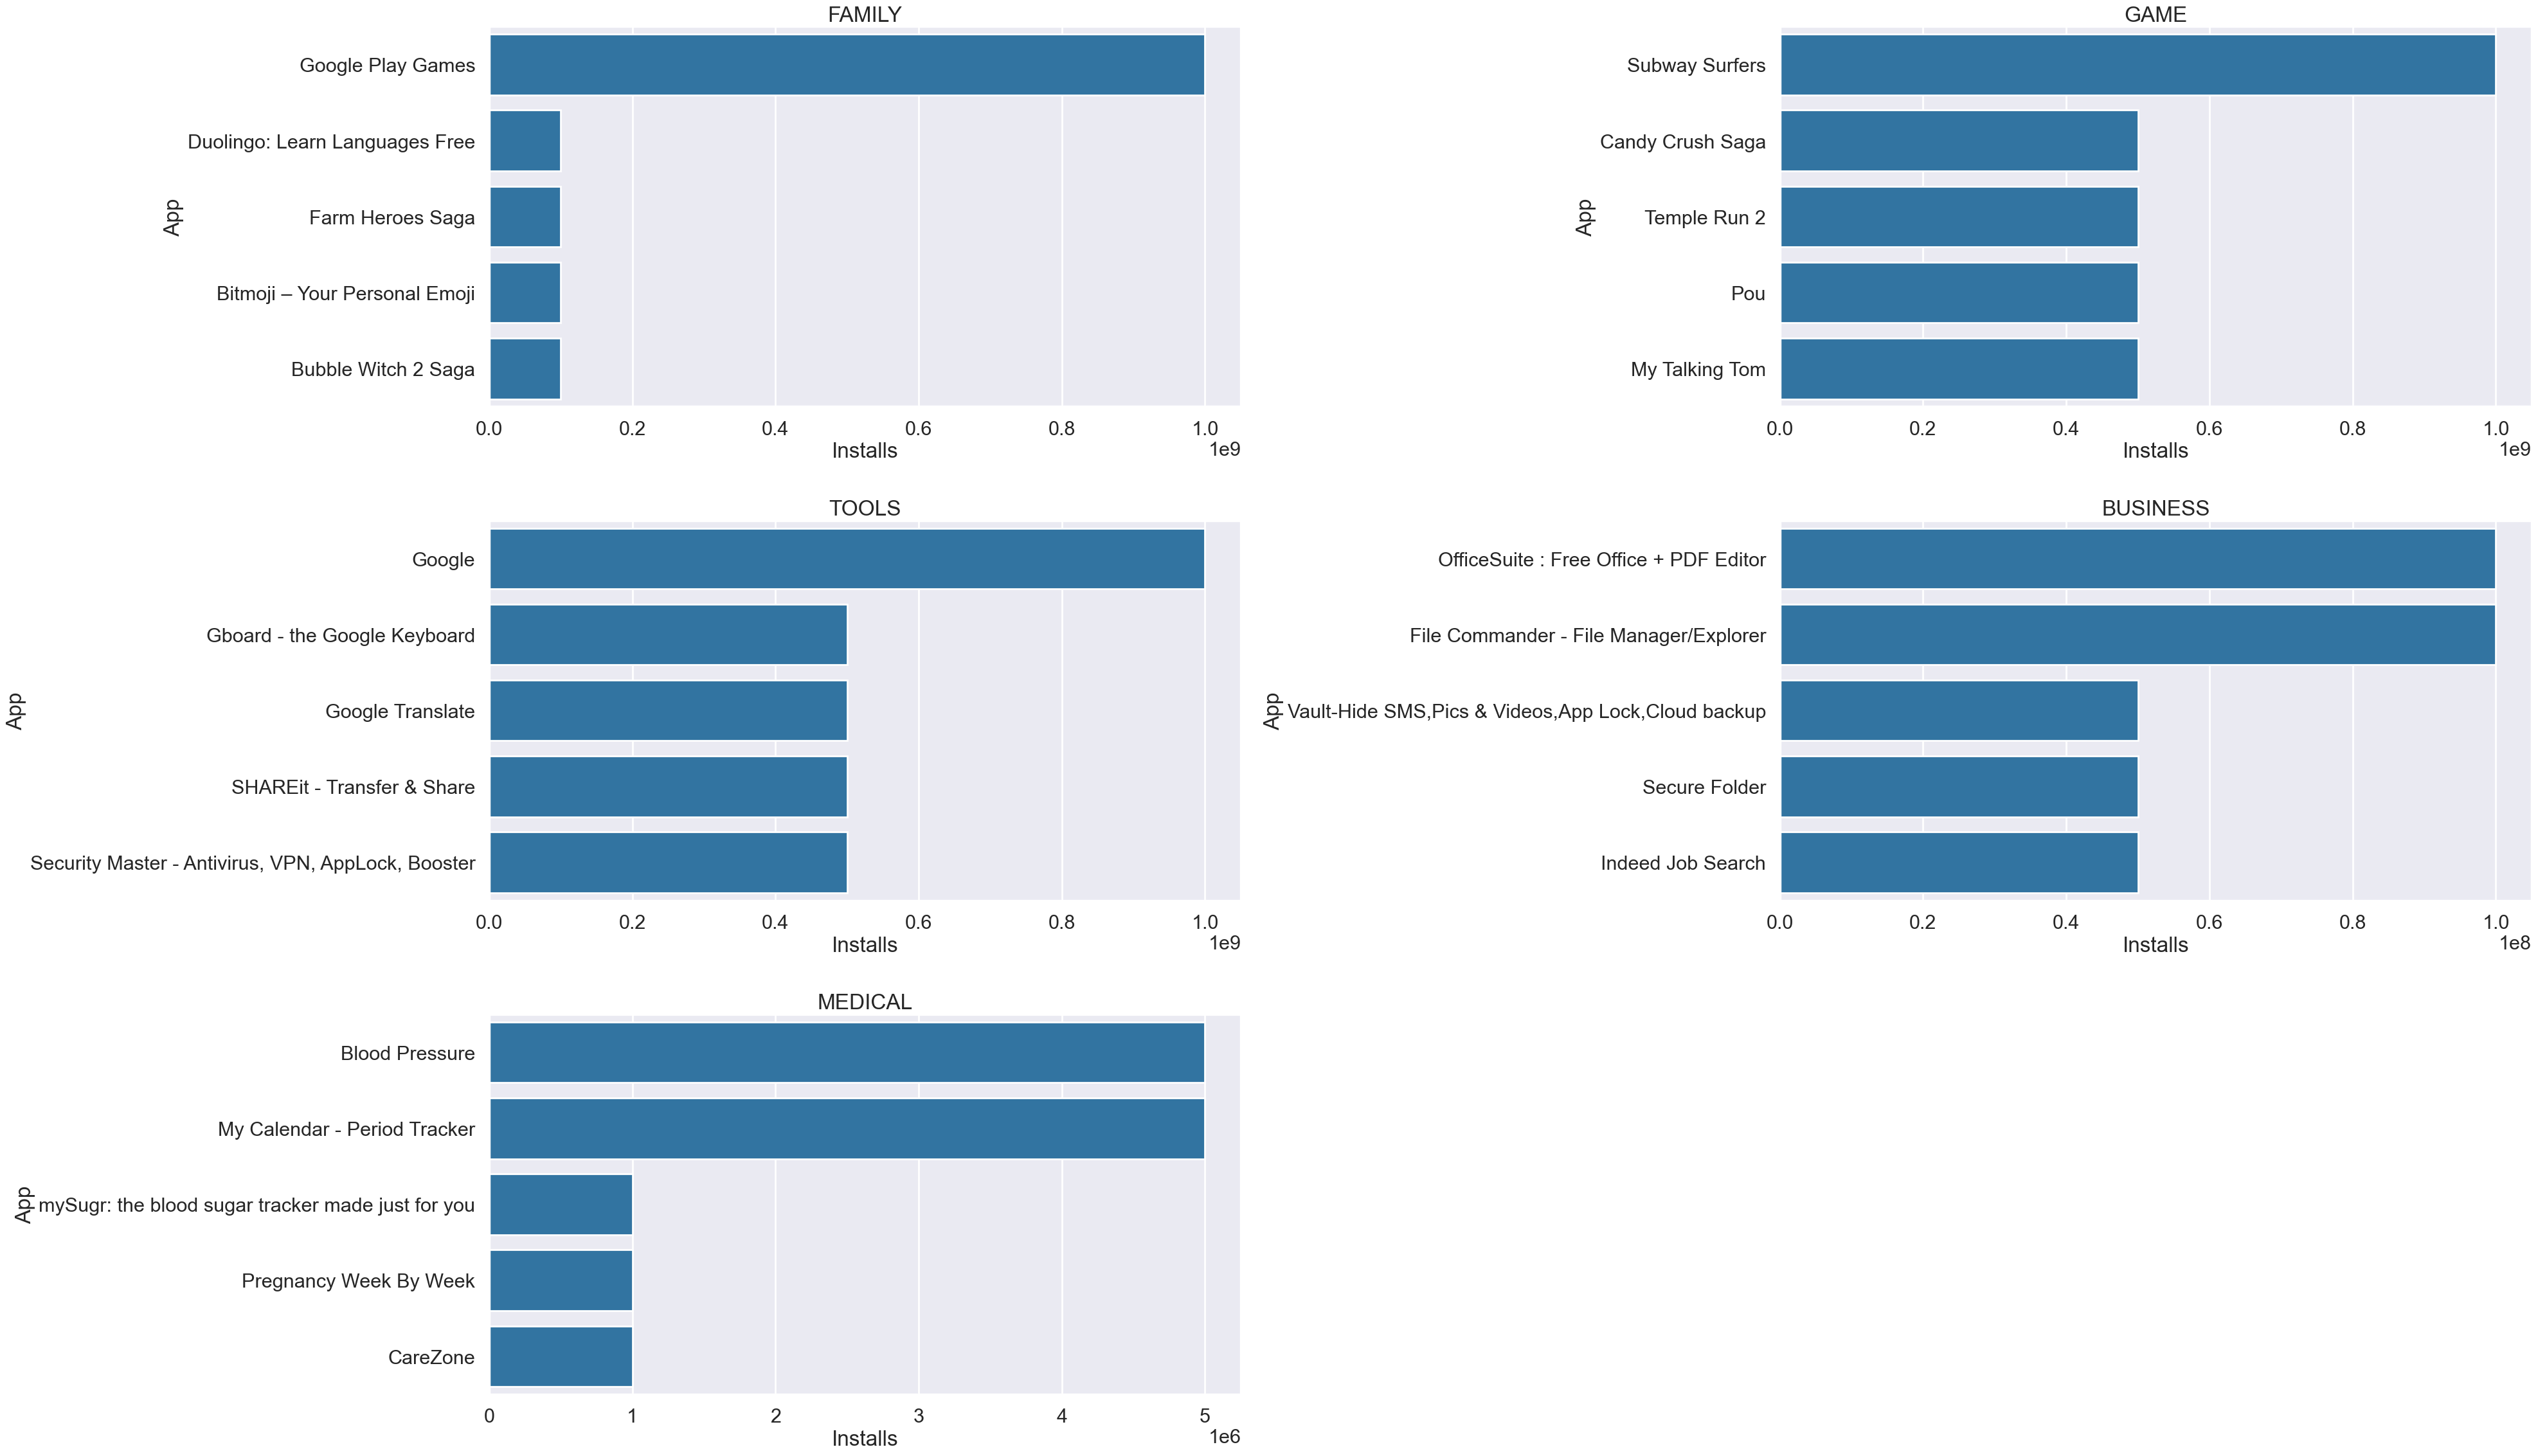

In [962]:

plt.figure(figsize=(40,30))
sns.set_context("poster")
sns.set_style("darkgrid")
for i, col in enumerate(Top_Category2,1):
    df2 = df1[df1['Category'] == col]
    df3 = df2.head(5)
    plt.subplot(4,2,i)

    sns.barplot(data=df3,x='Installs',y='App')
    plt.title(col)
plt.tight_layout()
plt.subplots_adjust(hspace= .3)
plt.show()



***

## How many apps are there on Google Play Store which get 5 ratings??

In [963]:
five_rated_app= df.groupby("App")['Rating'].mean().reset_index()

In [964]:
five_rated_app

,App,Rating
0,"""i DT"" Fútbol. Todos Somos Técnicos.",NaN
1,+Download 4 Instagram Twitter,4.5
2,- Free Comics - Comic Apps,3.5
3,.R,4.5
4,/u/app,4.7
...,...,...
9655,"뽕티비 - 개인방송, 인터넷방송, BJ방송",NaN
9656,💎 I'm rich,3.8
9657,"💘 WhatsLov: Smileys of love, stickers and GIF",4.6
9658,📏 Smart Ruler ↔️ cm/inch measuring for homework!,4.0


In [965]:
five_rated_app = five_rated_app[five_rated_app['Rating']==5 ]


In [966]:
five_rated_app

,App,Rating
36,211:CK,5.0
53,30WPM Amateur ham radio Koch CW Morse code tra...,5.0
78,420 BZ Budeze Delivery,5.0
120,A-Y Collection,5.0
155,AC DC Power Monitor,5.0
...,...,...
9445,ei Calc,5.0
9472,i am EB,5.0
9479,iCard BD Plus,5.0
9497,iReadMe,5.0


In [967]:
print("Number of 5 rated apps are: ",five_rated_app.shape[0])

Number of 5 rated apps are:  271


## Apps With No Rating

***

In [968]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_andriod_versions,Maximum_Andriod_Ver_Req,Unrated App
2989,GollerCepte Live Score,SPORTS,4.2,9992.0,31000000.0,1000000.0,Free,0.0,Everyone,Sports,6.5,4.1,False,Not Mentioned,2018,5,23,True,4.1,False
4970,Ad Block REMOVER - NEED ROOT,TOOLS,3.3,999.0,91000.0,100000.0,Free,0.0,Everyone,Tools,3.2,2.2,False,Not Mentioned,2013,12,17,True,2.2,False


In [969]:
Unrated_app = df[df['Unrated App'] == True]

In [973]:
Unrated_app.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price($),Content Rating,Genres,Current Ver,Android Ver,Size_varies_w_device,sub_genre,Last_Updated(Year),Last_Updated(Month)),Last_Updated(Day),Support_all_newer_andriod_versions,Maximum_Andriod_Ver_Req,Unrated App
3621,Voice Tables - no internet,PARENTING,NaN,970.0,71000000.0,100000.0,Free,0.0,Everyone,Parenting,2.0,4.0.3,False,Not Mentioned,2018,5,28,True,4.0.3,True
10808,lesparticuliers.fr,LIFESTYLE,NaN,96.0,1000000.0,50000.0,Free,0.0,Everyone,Lifestyle,1.5,2.3,False,Not Mentioned,2014,11,25,True,2.3,True
10818,Gold Quote - Gold.fr,FINANCE,NaN,96.0,1500000.0,10000.0,Free,0.0,Everyone,Finance,2.3,2.2,False,Not Mentioned,2016,5,19,True,2.2,True
9834,Recettes Faciles et Rapides,FOOD_AND_DRINK,NaN,95.0,12000000.0,50000.0,Free,0.0,Everyone,Food & Drink,3.0.1,2.3,False,Not Mentioned,2018,1,6,True,2.3,True
1177,Easy and Fast Recipes,FOOD_AND_DRINK,NaN,95.0,12000000.0,50000.0,Free,0.0,Everyone,Food & Drink,3.0.1,2.3,False,Not Mentioned,2018,1,6,True,2.3,True


In [972]:
df.to_csv("Updated_DataSet/Aryan_Dangol_Google_Play_Store_Cleaned.csv")